[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/NguyenVu04/band-tilt/blob/main/notebooks/01_eda.ipynb)

# 01 — Exploratory Data Analysis: Multi-Band RAN Tilt Optimization

**Inputs.** The simulation artifacts from notebook 00, read-only. **Outputs.** Tables and figures in
`reports/tables/01_eda` and `reports/figures/01_eda`; no data. No GPU is needed.

In [1]:
# Environment: locally, move to the project root; on Colab, clone the repository
# and install what Colab lacks. Extra Hydra overrides come from BAND_TILT_OVERRIDES.
REPO_URL = "https://github.com/NguyenVu04/band-tilt.git"
COLAB_PACKAGES = [("hydra", "hydra-core")]

import importlib.util
import os
import subprocess
import sys
from pathlib import Path

try:
    import google.colab  # noqa: F401

    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    root = Path("/content/band-tilt")
    if not root.exists():
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, str(root)], check=True)
    missing = [pip for module, pip in COLAB_PACKAGES if importlib.util.find_spec(module) is None]
    if missing:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing], check=True)
else:
    root = Path.cwd()
    while not (root / "pyproject.toml").exists() and root != root.parent:
        root = root.parent

os.chdir(root)
sys.path.insert(0, str(root))
CONFIG_OVERRIDES = os.environ.get("BAND_TILT_OVERRIDES", "").split()

In [2]:
%load_ext autoreload
%autoreload 2

from functools import partial
from itertools import combinations

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import ListedColormap
from scipy import ndimage
from scipy.spatial.distance import pdist

from src.config import load_config
from src.data import schema
from src.data.load import load_artifacts
from src.evaluation import compare, maps, plots
from src.evaluation.export import readable, save_table
from src.kpi import capacity
from src.kpi.overlap import overlap_neighbors
from src.optim.objective import KPI_NAMES, MAXIMISED, OBJECTIVE_NAMES, evaluate_kpis
from src.simulation.sample import CSV_COLUMNS
from src.utils.plotting import label, save_fig, setup_plotting
from src.utils.seed import set_seed

cfg = load_config(overrides=CONFIG_OVERRIDES)
set_seed(cfg.seed)
setup_plotting()
save_fig = partial(save_fig, in_colab=IN_COLAB, directory=Path("reports/figures/01_eda"))
save_table = partial(save_table, in_colab=IN_COLAB, directory=Path("reports/tables/01_eda"))
pd.set_option("display.precision", 4)
pd.set_option("display.max_columns", 40)

In [3]:
artifacts = load_artifacts(cfg)
ue, mdt, manifest, radio_map = artifacts.ue, artifacts.mdt, artifacts.manifest, artifacts.radio
rsrp = radio_map["rsrp_dbm"].astype(float)
sinr = radio_map["sinr_db"].astype(float)
tilt = radio_map["tilt_deg"].astype(float)
bands, tx_names = artifacts.band_labels, artifacts.tx_names
n_band, n_tx = len(bands), len(tx_names)
n_rows, n_cols = artifacts.shape
tile_m = float(radio_map["tile_size_m"])
extent = maps.extent_of(radio_map)
hole_dbm, weak_dbm = float(cfg.kpi.hole_dbm), float(cfg.kpi.weak_dbm)

cells = pd.DataFrame(
    [
        {
            "cell": str(c.name),
            "node": str(c.name).rsplit("c", 1)[0],
            "x": float(c.x),
            "y": float(c.y),
            "z": float(c.z),
            "azimuth_deg": float(c.azimuth_deg),
        }
        for c in cfg.simulation.transmitters.cells
    ]
)
nodes = cells.groupby("node")[["x", "y"]].first()
hotspots = pd.DataFrame(manifest["density"]["hotspots"])
spec = capacity.CapacitySpec.from_config(cfg, bands, n_tx)

# Frequency order low -> high, so "low band" never depends on the radio map's axis order.
by_frequency = [bands[i] for i in np.argsort(radio_map["band_hz"])]
low_band, mid_band, high_band = by_frequency

# Derived rasters shared by the sections below. Per-band best RSRP is -inf where no cell of the band reaches.
best_per_band = np.stack([capacity.max_rsrp(rsrp[[b]]) for b in range(n_band)])
best_overall = capacity.max_rsrp(rsrp)
coverage = maps.coverage_class(rsrp, cfg)
grid_x, grid_y = np.meshgrid(
    float(radio_map["origin_x"]) + (np.arange(n_cols) + 0.5) * tile_m,
    float(radio_map["origin_y"]) + (np.arange(n_rows) + 0.5) * tile_m,
)
node_distance = np.min([np.hypot(grid_x - n.x, grid_y - n.y) for n in nodes.itertuples()], axis=0)
served = capacity.serve_intervals(rsrp, sinr, bands, ue, cfg)
# Which UE rows are MDT reports; both files hold millimetre coordinates, so the join is exact.
in_mdt = (
    ue.merge(mdt[list(CSV_COLUMNS)], on=list(CSV_COLUMNS), how="left", indicator=True)["_merge"]
    .eq("both")
    .to_numpy()
)
peak_prb = capacity.demand_prb(rsrp, sinr, bands, ue, cfg)


def class_map(axis, values, names, colours, title):
    """Draw a categorical raster; ``values`` holds indices into ``names``, -1 for none."""
    image = np.where(values >= 0, values, np.nan)
    axis.imshow(image, origin="lower", extent=extent, cmap=ListedColormap(colours),
                vmin=-0.5, vmax=len(names) - 0.5, interpolation="nearest")
    axis.scatter(nodes["x"], nodes["y"], marker="^", s=45, color="crimson", zorder=3)
    handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in colours]
    axis.legend(handles, names, loc="lower left", fontsize=8, frameon=True)
    axis.set(title=title, xlabel="x [m]", ylabel="y [m]")
    axis.grid(False)

## 1. Analysis Objectives

This notebook describes the data before any optimization reads it:

1. What data is available, and how is it spread across nodes, cells and frequency bands?
2. Are there missing values, invalid measurements, duplicated observations or outliers?
3. How does coverage differ between frequency bands?
4. Where do **coverage holes**, **weak coverage** and **excessive co-band overlap** occur?
5. How do antenna configuration, frequency, signal strength and UE demand relate?
6. Which network characteristics matter for the optimization model?

## 2. Dataset Overview

### 2.1 Dataset Description

The dataset is one simulated scenario, written by notebook 00 (`task simulation`) in four artifacts:

| Artifact | Unit of observation | Content |
| --- | --- | --- |
| `data/interim/radio_map.npz` | grid tile × cell × band | Ray-traced `rsrp_dbm` and `sinr_db` on a 20 m grid (NaN where no path), the tilt each cell-band was solved at, grid geometry, solver settings |
| `data/external/ue_positions.csv` | UE × 15-minute interval | UE position `x, y, z`, its tile `tile_row, tile_col`, interval `t_index, t_s`, and the mixture `component` it was drawn from (`-1` background, `0..` hotspot) |
| `data/interim/mdt.csv` | served UE × 15-minute interval | The UE rows the serving rule admits at the current tilts, with the serving cell-band's `rsrp_dbm`. The search scores load on it; evaluation uses every UE row |
| `data/external/scenario.json` | scenario | Scenario id, grid, hotspot centres and shapes, per-interval UE counts and component masses |

The cell layout (position, mast height, azimuth, tilt bounds, PRB limit) is in `configs/simulation.yaml`.

| Category | Variables in this dataset |
| --- | --- |
| Spatial | tile grid (`origin_x`, `origin_y`, `tile_size_m`), UE `x`, `y`, `tile_row`, `tile_col` |
| Cell | node `n0..n3`, cell `nXcY`; no separate sector id — each cell is one sector |
| Frequency | `band_label`, `band_hz` |
| Antenna | `tilt_deg`, `azimuth_deg`, mast height `z` |
| Radio | `rsrp_dbm`, `sinr_db` (no RSRQ is simulated) |
| Traffic | UE rows per interval; PRB demand derived by `src/kpi/capacity.py` |
| Metadata | `scenario_id`, solver settings, `t_index`, `t_s` |

### 2.2 Dataset Dimensions

In [4]:
overview = pd.DataFrame(
    {
        "Value": {
            "Nodes (sites)": cells["node"].nunique(),
            "Cells": n_tx,
            "Frequency bands": n_band,
            "Cell-band pairs (tilt decision variables)": n_tx * n_band,
            "Grid tiles": n_rows * n_cols,
            "Grid size [rows x cols]": f"{n_rows} x {n_cols}",
            "Tile size [m]": tile_m,
            "Grid area [km²]": round(n_rows * n_cols * tile_m**2 / 1e6, 2),
            "Radio-map values (band x cell x tile)": rsrp.size,
            "Time intervals": int(manifest["time"]["n_intervals"]),
            "UE rows (UE x interval)": len(ue),
            "MDT rows (served UE x interval)": len(mdt),
            "MDT share of UE rows": round(len(mdt) / len(ue), 4),
            "UEs per interval [min-max]": f"{ue.groupby('t_index').size().min()}-{ue.groupby('t_index').size().max()}",
            "Distinct UE tiles": ue[["tile_row", "tile_col"]].drop_duplicates().shape[0],
            "Demand hotspots": len(hotspots),
            "Scenario id": artifacts.scenario_id,
        }
    }
).rename_axis("Property").reset_index()
save_table(overview, "dataset_overview")
overview

,Property,Value
0,Nodes (sites),4
1,Cells,12
2,Frequency bands,3
3,Cell-band pairs (tilt decision variables),36
4,Grid tiles,101060
5,Grid size [rows x cols],326 x 310
6,Tile size [m],20.0
7,Grid area [km²],40.42
8,Radio-map values (band x cell x tile),3638160
9,Time intervals,672


### Key takeaway

One scenario (`scn_7d938e15f9ac4618`): 4 co-located nodes × 3 cells × 3 bands (36 tilt variables), solved on a
326 × 310 grid of 20 m tiles (≈40 km²), with 10 066 UE rows drawn over 672 fifteen-minute intervals. Every band is
solved for every cell on the same tiles, so layers can be compared directly tile by tile. The UE sample is thin
(10–20 UEs per interval, 5 141 distinct tiles), so per-tile demand is sparse.

## 3. Data Schema and Feature Types

### 3.1 Feature Summary

In [5]:
roles = {
    "t_index": "Identifier (interval)",
    "t_s": "Time [s]",
    "x": "Spatial [m]",
    "y": "Spatial [m]",
    "z": "Spatial [m]",
    "tile_col": "Identifier (grid column)",
    "tile_row": "Identifier (grid row)",
    "component": "Categorical (mixture component)",
}
ue_schema = pd.DataFrame(
    {
        "Column": ue.columns,
        "Role": [roles.get(c, "") for c in ue.columns],
        "dtype": ue.dtypes.astype(str).to_numpy(),
        "Distinct values": ue.nunique().to_numpy(),
        "Min": ue.min().to_numpy(),
        "Max": ue.max().to_numpy(),
    }
)
radio_schema = pd.DataFrame(
    [
        {"Array": k, "Shape": str(v.shape), "dtype": str(v.dtype)}
        for k, v in radio_map.items()
        if v.ndim > 0
    ]
)
save_table(ue_schema, "ue_schema")
display(ue_schema)
radio_schema

,Column,Role,dtype,Distinct values,Min,Max
0,t_index,Identifier (interval),int64,672,0.000,671.000
1,t_s,Time [s],float64,672,0.000,603900.000
2,x,Spatial [m],float64,10054,-3032.376,3029.093
3,y,Spatial [m],float64,10031,-3246.602,3253.245
4,z,Spatial [m],float64,1,1.500,1.500
5,tile_col,Identifier (grid column),int64,305,2.000,306.000
6,tile_row,Identifier (grid row),int64,326,0.000,325.000
7,component,Categorical (mixture component),int64,5,-1.000,3.000


,Array,Shape,dtype
0,rsrp_dbm,"(3, 12, 326, 310)",float32
1,sinr_db,"(3, 12, 326, 310)",float32
2,band_hz,"(3,)",float64
3,band_label,"(3,)",<U5
4,tilt_deg,"(3, 12)",float64
5,tx_name,"(12,)",<U4
6,tile_centre,"(326, 310, 3)",float64


### 3.2 Data Types

- `t_index`, `tile_row`, `tile_col` and `component` are identifiers or categories stored as `int64`; none of them
  is used arithmetically except as an index. `component` is categorical (`-1` = uniform background).
- Coordinates are metres in the scene frame, the same frame as the cell positions and the grid origin.
- Bands are categorical labels (`band_label`) with their carrier in `band_hz`; the radio-map axes follow
  `band_label` order, not frequency order, so this notebook sorts by `band_hz` wherever low/mid/high matters.
- RSRP is in dBm and SINR in dB, `float32` in the archive, NaN where the ray tracer found no path.

## 4. Data Quality Assessment

### 4.1 Missing Values

The UE table should have no gaps. In the radio map, NaN means *no propagation path*, which is physical
information, not a pipeline gap; `src/kpi/capacity.finite` turns it into `-inf` so a no-path tile counts as a hole.

In [6]:
ue_missing = ue.isna().sum().rename("Missing").to_frame().assign(**{"Missing [%]": lambda f: 100 * f["Missing"] / len(ue)})
display(ue_missing.T)

missing = pd.DataFrame(
    [
        {
            "Band": label(band),
            "No-path cell-tile pairs [%]": 100 * np.isnan(rsrp[b]).mean(),
            "Tiles no cell of the band reaches [%]": 100 * (~np.isfinite(best_per_band[b])).mean(),
            "UE rows no cell of the band reaches [%]": 100 * (~np.isfinite(best_per_band[b][ue.tile_row, ue.tile_col])).mean(),
            "SINR NaN exactly where RSRP NaN": bool((np.isnan(rsrp[b]) == np.isnan(sinr[b])).all()),
        }
        for b, band in enumerate(bands)
    ]
    + [
        {
            "Band": "All bands combined",
            "No-path cell-tile pairs [%]": 100 * np.isnan(rsrp).mean(),
            "Tiles no cell of the band reaches [%]": 100 * (~np.isfinite(best_overall)).mean(),
            "UE rows no cell of the band reaches [%]": 100 * (~np.isfinite(best_overall[ue.tile_row, ue.tile_col])).mean(),
            "SINR NaN exactly where RSRP NaN": bool((np.isnan(rsrp) == np.isnan(sinr)).all()),
        }
    ]
)
save_table(missing, "missing_values")
missing

,t_index,t_s,x,y,z,tile_col,tile_row,component
Missing,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Missing [%],0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


,Band,No-path cell-tile pairs [%],Tiles no cell of the band reaches [%],UE rows no cell of the band reaches [%],SINR NaN exactly where RSRP NaN
0,2600 MHz,68.2293,18.0457,33.0022,True
1,1800 MHz,68.4032,18.2397,33.5684,True
2,700 MHz,62.5214,14.5933,29.7437,True
3,All bands combined,66.3846,9.7101,25.1639,True


In [7]:
# Where no path is found: share of tiles with no path on any band, by distance to the nearest node.
ring_edges = np.arange(0, node_distance.max() + 500, 500)
rings = pd.cut(node_distance.ravel(), ring_edges)
no_path_by_distance = (
    pd.DataFrame({"Distance to nearest node [m]": rings, "no_path": ~np.isfinite(best_overall).ravel()})
    .groupby("Distance to nearest node [m]", observed=True)["no_path"]
    .agg(["size", "mean"])
    .rename(columns={"size": "Tiles", "mean": "Share with no path"})
)
no_path_by_distance

,Tiles,Share with no path
Distance to nearest node [m],,
"(0.0, 500.0]",7863,0.0014
"(500.0, 1000.0]",14449,0.0028
"(1000.0, 1500.0]",17160,0.0073
"(1500.0, 2000.0]",20601,0.0547
"(2000.0, 2500.0]",21402,0.1099
"(2500.0, 3000.0]",13699,0.2320
"(3000.0, 3500.0]",5295,0.4823
"(3500.0, 4000.0]",591,0.7191


### Key takeaway

The UE table has no missing values. Radio-map NaN is systematic and physical: SINR is NaN exactly where RSRP is,
and the share of tiles with no path on any band rises from under 1 % within 1.5 km of a node to about half beyond
3 km. It is lack of coverage, not a pipeline gap, and is kept as `-inf` (a hole) rather than imputed. 700 MHz
reaches the most tiles. A quarter of UE rows stand on tiles no cell reaches — most of them from one hotspot (§10).

### 4.2 Duplicate Records

UE positions are continuous draws, so a repeated row is a writer fault. Several UEs sharing one tile in one
interval is expected and is not a duplicate.

In [8]:
duplicates = pd.DataFrame(
    [
        {"Key": "All columns", "Duplicated rows": int(ue.duplicated().sum())},
        {"Key": "(t_index, x, y)", "Duplicated rows": int(ue.duplicated(["t_index", "x", "y"]).sum())},
        {"Key": "(t_index, tile_row, tile_col) — shared tiles, expected", "Duplicated rows": int(ue.duplicated(["t_index", "tile_row", "tile_col"]).sum())},
        {"Key": "Radio map: (band, cell) layers identical", "Duplicated rows": int(sum(
            np.array_equal(rsrp[b, i], rsrp[b, j], equal_nan=True)
            for b in range(n_band) for i, j in combinations(range(n_tx), 2)
        ))},
    ]
)
save_table(duplicates, "duplicates")
duplicates

,Key,Duplicated rows
0,All columns,0
1,"(t_index, x, y)",0
2,"(t_index, tile_row, tile_col) — shared tiles, ...",38
3,"Radio map: (band, cell) layers identical",0


### Key takeaway

No duplicated UE rows on any key, and no two cell-band layers are identical. The 38 rows that share an
`(interval, tile)` are distinct UEs on the same tile, which is expected; nothing is removed or aggregated.

### 4.3 Invalid Values and Physical Constraints

First the contract checks of `src/data/schema.py` (the same ones `task preprocess` enforces), then the
physical ranges. Each bound names its source. Nothing is removed here.

In [9]:
contract = readable(schema.verify(artifacts, cfg))
save_table(contract, "schema_checks")
display(contract)

heard = rsrp[np.isfinite(rsrp)]
at_ue = rsrp[:, :, ue["tile_row"].to_numpy(), ue["tile_col"].to_numpy()]
heard_at_ue = at_ue[np.isfinite(at_ue)]
bounds = np.array([[c.tilt[band].bounds_deg for c in cfg.simulation.transmitters.cells] for band in bands])
configured_hz = {str(b.name): float(b.frequency) for b in cfg.simulation.radio_map.bands}

physical = pd.DataFrame(
    [
        ("RSRP below -156 dBm, all tiles", "NR SS-RSRP reporting range lower bound, 3GPP TS 38.133 (to be verified)", f"{(heard < -156.0).mean():.2%} of cell-band-tile values"),
        ("RSRP below -156 dBm, UE tiles", "as above", f"{(heard_at_ue < -156.0).mean():.2%} of cell-band values at UEs"),
        ("RSRP above the RS transmit power", "configs/simulation.yaml simulation.antenna.power_rs", f"{(heard > float(cfg.simulation.antenna.power_rs)).mean():.2%}"),
        ("SINR range", "sinr_db, finite values", f"{np.nanmin(sinr):.1f} to {np.nanmax(sinr):.1f} dB"),
        ("Tilt inside its bounds", "configs/simulation.yaml cells[].tilt[band].bounds_deg", f"{int(((tilt < bounds[..., 0]) | (tilt > bounds[..., 1])).sum())} of {tilt.size} outside"),
        ("Azimuth in [0°, 360°)", "geometry", f"{int(((cells.azimuth_deg < 0) | (cells.azimuth_deg >= 360)).sum())} of {n_tx} outside"),
        ("band_hz matches the configured carrier", "configs/simulation.yaml radio_map.bands", str(all(configured_hz[b] == float(h) for b, h in zip(bands, radio_map["band_hz"])))),
        ("Cell positions inside the grid", "grid extent", f"{int(((cells.x < extent[0]) | (cells.x > extent[1]) | (cells.y < extent[2]) | (cells.y > extent[3])).sum())} of {n_tx} outside"),
    ],
    columns=["Check", "Reference", "Result"],
)
save_table(physical, "physical_checks")
physical

,Check,source,Holds,violations
0,npz tx_name matches the configured cells,configs/simulation.yaml,True,0
1,npz band_label matches the configured bands,configs/simulation.yaml,True,0
2,npz scenario_id matches the manifest,scenario.json,True,0
3,npz grid matches the manifest grid,scenario.json,True,0
4,npz ue_height_m matches the config,configs/simulation.yaml,True,0
5,ue columns are the declared set,configs/simulation.yaml,True,0
6,npz sinr_db has the shape of rsrp_dbm,radio_map.npz,True,0
7,z equals the configured UE height,configs/simulation.yaml,True,0
8,0 <= tile_row < n_rows,scenario.json,True,0
9,0 <= tile_col < n_cols,scenario.json,True,0


,Check,Reference,Result
0,"RSRP below -156 dBm, all tiles","NR SS-RSRP reporting range lower bound, 3GPP T...",4.80% of cell-band-tile values
1,"RSRP below -156 dBm, UE tiles",as above,5.38% of cell-band values at UEs
2,RSRP above the RS transmit power,configs/simulation.yaml simulation.antenna.pow...,0.00%
3,SINR range,"sinr_db, finite values",-158.0 to 59.2 dB
4,Tilt inside its bounds,configs/simulation.yaml cells[].tilt[band].bou...,0 of 36 outside
5,"Azimuth in [0°, 360°)",geometry,0 of 12 outside
6,band_hz matches the configured carrier,configs/simulation.yaml radio_map.bands,True
7,Cell positions inside the grid,grid extent,0 of 12 outside


### Key takeaway

All 22 contract checks of `src/data/schema.py` hold, the five MDT checks included. No RSRP exceeds the RS transmit power, every tilt is inside
its bounds, azimuths are valid and every cell sits inside the grid. About 5 % of reached cell-band-tile values are
below −156 dBm, the NR reporting floor; they are all far below `kpi.hole_dbm`, so they classify as holes either way
and are retained (Appendix B).

## 5. Univariate Analysis

### 5.1 Frequency-Band Distribution

Every band is solved for every cell on the same grid, so the question is not how many rows a band has but how
much of the area and of the UE population it actually reaches.

In [10]:
representation = pd.DataFrame(
    [
        {
            "Band": label(band),
            "Carrier [MHz]": float(radio_map["band_hz"][b]) / 1e6,
            "Bandwidth [MHz]": next(float(x.bandwidth) for x in cfg.simulation.radio_map.bands if x.name == band) / 1e6,
            "PRB limit per cell": int(spec.max_prb[b, 0]),
            "Tiles reached [%]": 100 * np.isfinite(best_per_band[b]).mean(),
            "Tiles above hole threshold [%]": 100 * (best_per_band[b] > hole_dbm).mean(),
            "UE rows above hole threshold [%]": 100 * (best_per_band[b][ue.tile_row, ue.tile_col] > hole_dbm).mean(),
        }
        for b, band in enumerate(bands)
    ]
)
save_table(representation, "band_representation")
representation

,Band,Carrier [MHz],Bandwidth [MHz],PRB limit per cell,Tiles reached [%],Tiles above hole threshold [%],UE rows above hole threshold [%]
0,2600 MHz,2600.0,40.0,216,81.9543,63.0190,51.3411
1,1800 MHz,1800.0,20.0,106,81.7603,67.9784,55.8315
2,700 MHz,700.0,10.0,52,85.4067,78.0823,64.3255


### 5.2 Antenna Tilt Distribution

In [11]:
tilt_table = pd.DataFrame(tilt, index=[label(b) for b in bands], columns=tx_names)
display(tilt_table)
tilt_summary = pd.DataFrame(
    [
        {
            "Band": label(band),
            "Distinct tilts": np.unique(tilt[b]).size,
            "Min [°]": tilt[b].min(),
            "Max [°]": tilt[b].max(),
            "Bounds [°]": f"{bounds[b, :, 0].min():g}-{bounds[b, :, 1].max():g}",
            "Headroom to max bound [°]": float((bounds[b, :, 1] - tilt[b]).min()),
        }
        for b, band in enumerate(bands)
    ]
)
save_table(tilt_summary, "tilt_summary")
tilt_summary

,n0c0,n0c1,n0c2,n1c0,n1c1,n1c2,n2c0,n2c1,n2c2,n3c0,n3c1,n3c2
2600 MHz,12.0,12.0,12.0,12.0,12.0,12.0,12.0,12.0,12.0,12.0,12.0,12.0
1800 MHz,12.0,12.0,12.0,12.0,12.0,12.0,12.0,12.0,12.0,12.0,12.0,12.0
700 MHz,12.0,12.0,12.0,12.0,12.0,12.0,12.0,12.0,12.0,12.0,12.0,12.0


,Band,Distinct tilts,Min [°],Max [°],Bounds [°],Headroom to max bound [°]
0,2600 MHz,1,12.0,12.0,0-15,3.0
1,1800 MHz,1,12.0,12.0,0-15,3.0
2,700 MHz,1,12.0,12.0,0-15,3.0


**Tilt.** Every one of the 36 cell-bands is at 12°, inside the 0–15° bounds: one configuration, no variation across
bands, cells or nodes. There is 12° of room to uptilt and 3° to downtilt. A histogram or box plot adds nothing, and
this dataset holds no information on how tilt moves coverage — that comes from the re-solved candidates in 03a/03b.

### 5.3 Signal Strength Distribution

Per tile, the strongest cell of each band (the per-band best server), over tiles that band reaches.

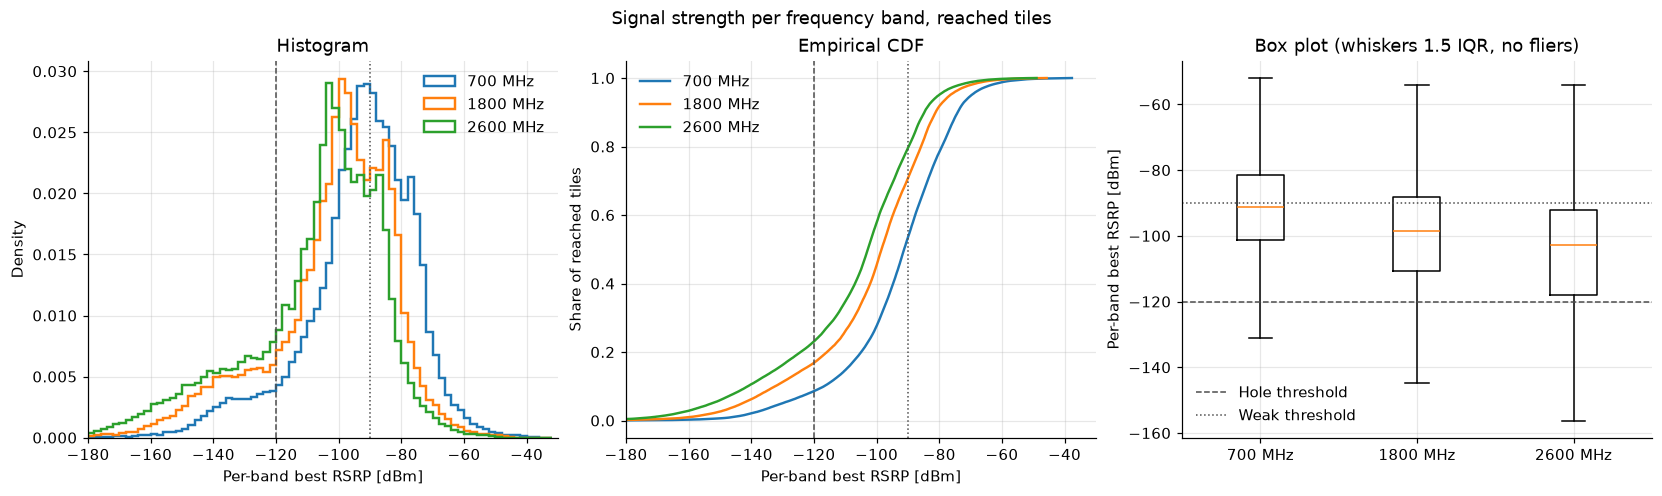

,Band,Mean [dBm],Std [dB],P5 [dBm],Median [dBm],P95 [dBm],Reached tiles at or below hole threshold [%]
0,700 MHz,-93.4327,17.8665,-130.2082,-91.2286,-69.7605,8.5759
1,1800 MHz,-102.0188,20.1524,-142.9009,-98.4281,-76.5558,16.8565
2,2600 MHz,-107.6293,22.2302,-152.6600,-102.8263,-80.1517,23.1047


In [12]:
finite_band = {band: best_per_band[b][np.isfinite(best_per_band[b])] for b, band in enumerate(bands)}

figure, axes = plt.subplots(1, 3, figsize=(15.0, 4.4), constrained_layout=True)
for band in by_frequency:
    values = finite_band[band]
    axes[0].hist(values, bins=np.arange(-180, -30, 2), histtype="step", lw=1.6, label=label(band), density=True)
    ordered = np.sort(values)
    axes[1].plot(ordered, np.arange(1, ordered.size + 1) / ordered.size, lw=1.6, label=label(band))
axes[2].boxplot([finite_band[b] for b in by_frequency], tick_labels=[label(b) for b in by_frequency], showfliers=False)
for axis in axes[:2]:
    axis.axvline(hole_dbm, color="0.3", ls="--", lw=1)
    axis.axvline(weak_dbm, color="0.3", ls=":", lw=1)
    axis.set_xlim(-180, -30)
    axis.legend()
axes[2].axhline(hole_dbm, color="0.3", ls="--", lw=1, label="Hole threshold")
axes[2].axhline(weak_dbm, color="0.3", ls=":", lw=1, label="Weak threshold")
axes[2].legend()
axes[0].set(xlabel="Per-band best RSRP [dBm]", ylabel="Density", title="Histogram")
axes[1].set(xlabel="Per-band best RSRP [dBm]", ylabel="Share of reached tiles", title="Empirical CDF")
axes[2].set(ylabel="Per-band best RSRP [dBm]", title="Box plot (whiskers 1.5 IQR, no fliers)")
figure.suptitle("Signal strength per frequency band, reached tiles")
save_fig(figure, "rsrp_distribution")
plt.show()

rsrp_stats = pd.DataFrame(
    [
        {
            "Band": label(band),
            "Mean [dBm]": finite_band[band].mean(),
            "Std [dB]": finite_band[band].std(),
            "P5 [dBm]": np.percentile(finite_band[band], 5),
            "Median [dBm]": np.median(finite_band[band]),
            "P95 [dBm]": np.percentile(finite_band[band], 95),
            "Reached tiles at or below hole threshold [%]": 100 * (finite_band[band] <= hole_dbm).mean(),
        }
        for band in by_frequency
    ]
)
save_table(rsrp_stats, "rsrp_statistics")
rsrp_stats

### Key takeaway

Signal falls with frequency, as expected: median per-band best RSRP is about −91 dBm at 700 MHz, −98 dBm at
1800 MHz and −103 dBm at 2600 MHz. Spread grows with frequency too (std ≈ 18 → 20 → 22 dB), and the weak tail grows
with it: 9 %, 17 % and 23 % of reached tiles sit at or below the hole threshold.

## 6. Multi-Band Coverage Analysis

### 6.1 Coverage by Frequency Band

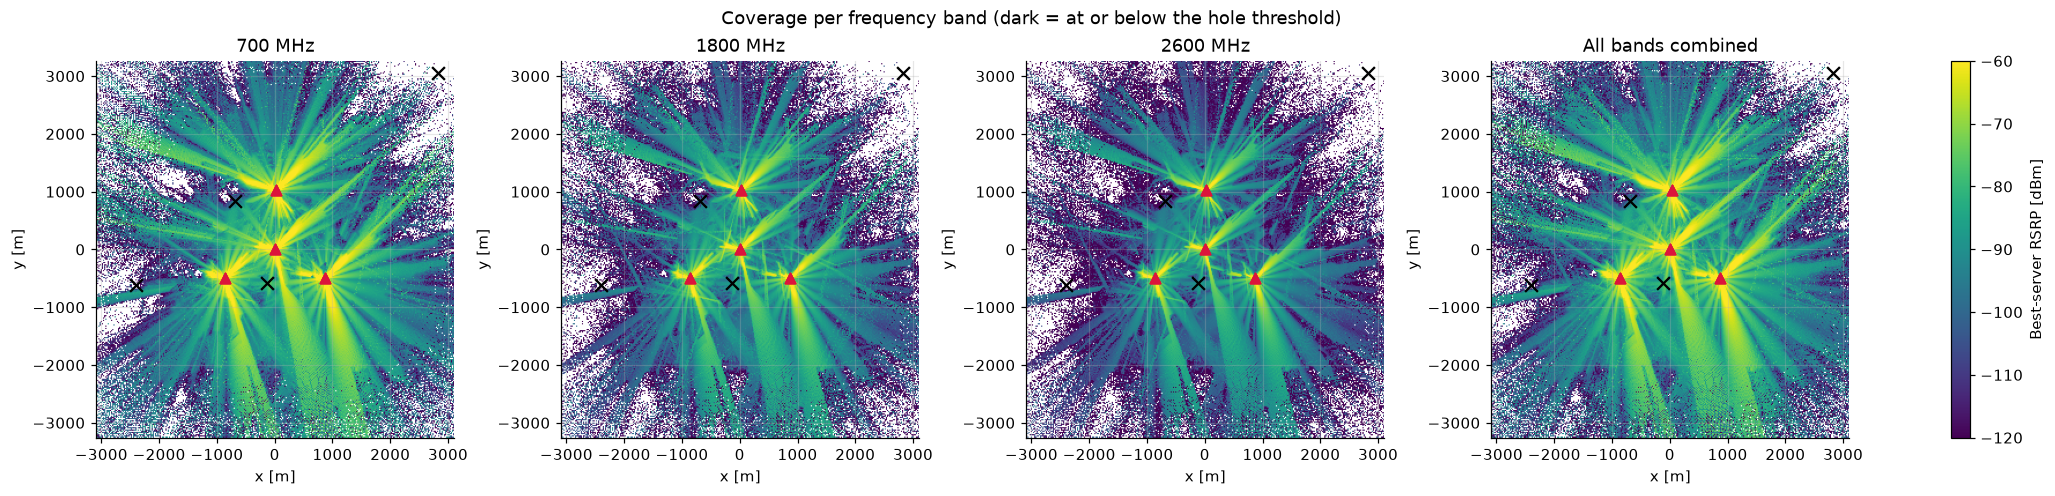

In [13]:
figure = plots.map_row(
    {label(band): best_per_band[bands.index(band)] for band in by_frequency}
    | {"All bands combined": best_overall},
    radio_map,
    colorbar_label="Best-server RSRP [dBm]",
    vmin=maps.RSRP_LIMITS[0],
    vmax=maps.RSRP_LIMITS[1],
    cells=cells,
    hotspots=hotspots,
)
figure.suptitle("Coverage per frequency band (dark = at or below the hole threshold)")
save_fig(figure, "coverage_per_band")
plt.show()

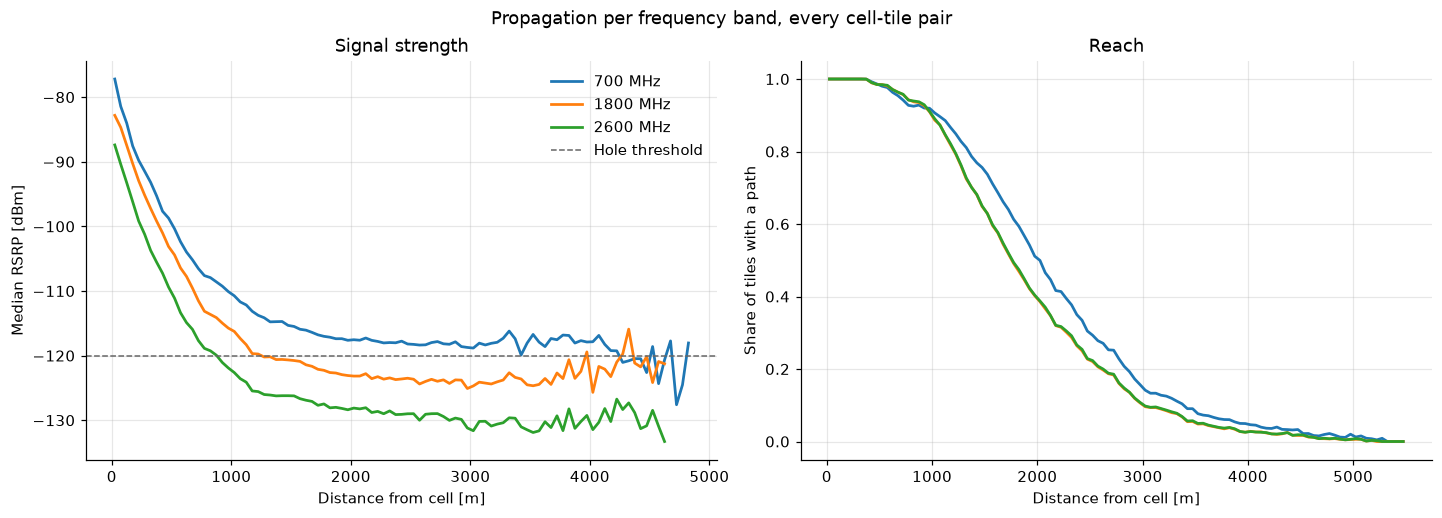

,Layer,Coverage holes [%],Weak coverage [%],Good coverage [%]
0,700 MHz,21.9177,38.3505,39.7318
1,1800 MHz,32.0216,44.0491,23.9293
2,2600 MHz,36.9810,46.2646,16.7544
3,All bands combined,18.4029,40.6303,40.9668


In [14]:
distance = np.stack([np.hypot(grid_x - row.x, grid_y - row.y) for row in cells.itertuples()])
edges = np.arange(0.0, distance.max() + 50.0, 50.0)
midpoints = 0.5 * (edges[:-1] + edges[1:])
which_bin = np.digitize(distance, edges) - 1
MIN_TILES = 30  # bins with fewer reached tiles are not drawn

figure, axes = plt.subplots(1, 2, figsize=(13.0, 4.6), constrained_layout=True)
for band in by_frequency:
    layer = rsrp[bands.index(band)]
    reached = np.isfinite(layer)
    medians, shares = [], []
    for bin_index in range(len(midpoints)):
        in_bin = which_bin == bin_index
        hit = in_bin & reached
        medians.append(np.median(layer[hit]) if hit.sum() >= MIN_TILES else np.nan)
        shares.append(hit.sum() / in_bin.sum() if in_bin.any() else np.nan)
    axes[0].plot(midpoints, medians, lw=1.8, label=label(band))
    axes[1].plot(midpoints, shares, lw=1.8, label=label(band))
axes[0].axhline(hole_dbm, color="0.4", ls="--", lw=1, label="Hole threshold")
axes[0].set(xlabel="Distance from cell [m]", ylabel="Median RSRP [dBm]", title="Signal strength")
axes[1].set(xlabel="Distance from cell [m]", ylabel="Share of tiles with a path", title="Reach")
axes[0].legend()
figure.suptitle("Propagation per frequency band, every cell-tile pair")
save_fig(figure, "band_propagation")
plt.show()


def classes(best):
    """Share of tiles per coverage class, in percent."""
    return {
        "Coverage holes [%]": 100.0 * (best <= hole_dbm).mean(),
        "Weak coverage [%]": 100.0 * ((best > hole_dbm) & (best <= weak_dbm)).mean(),
        "Good coverage [%]": 100.0 * (best > weak_dbm).mean(),
    }


coverage_classes = pd.DataFrame(
    [{"Layer": label(band), **classes(best_per_band[bands.index(band)])} for band in by_frequency]
    + [{"Layer": "All bands combined", **classes(best_overall)}]
)
save_table(coverage_classes, "coverage_classes_per_band")
coverage_classes

### Key takeaway

The maps agree with propagation physics: each band covers the same footprint around the nodes, and 700 MHz
extends it farthest. Alone, 700 MHz leaves 22 % of the grid as holes, against 32 % at 1800 MHz and 37 % at
2600 MHz. Combining all bands only lowers that to 18 %, so the coverage floor is set by the low band. The higher
bands add little area that 700 MHz does not already reach.

### 6.2 Serving Cell / Serving Band Distribution

Two views. The **strongest cell-band** is the pure radio argmax $s(g) = \arg\max_{i,b} R_{i,b}(g)$. The
**serving-rule band** is what `src/kpi/capacity.py` would pick before PRB limits: the most preferred band
(`kpi.capacity.band_preference`) whose strongest cell clears `kpi.capacity.rsrp_threshold_dbm`.

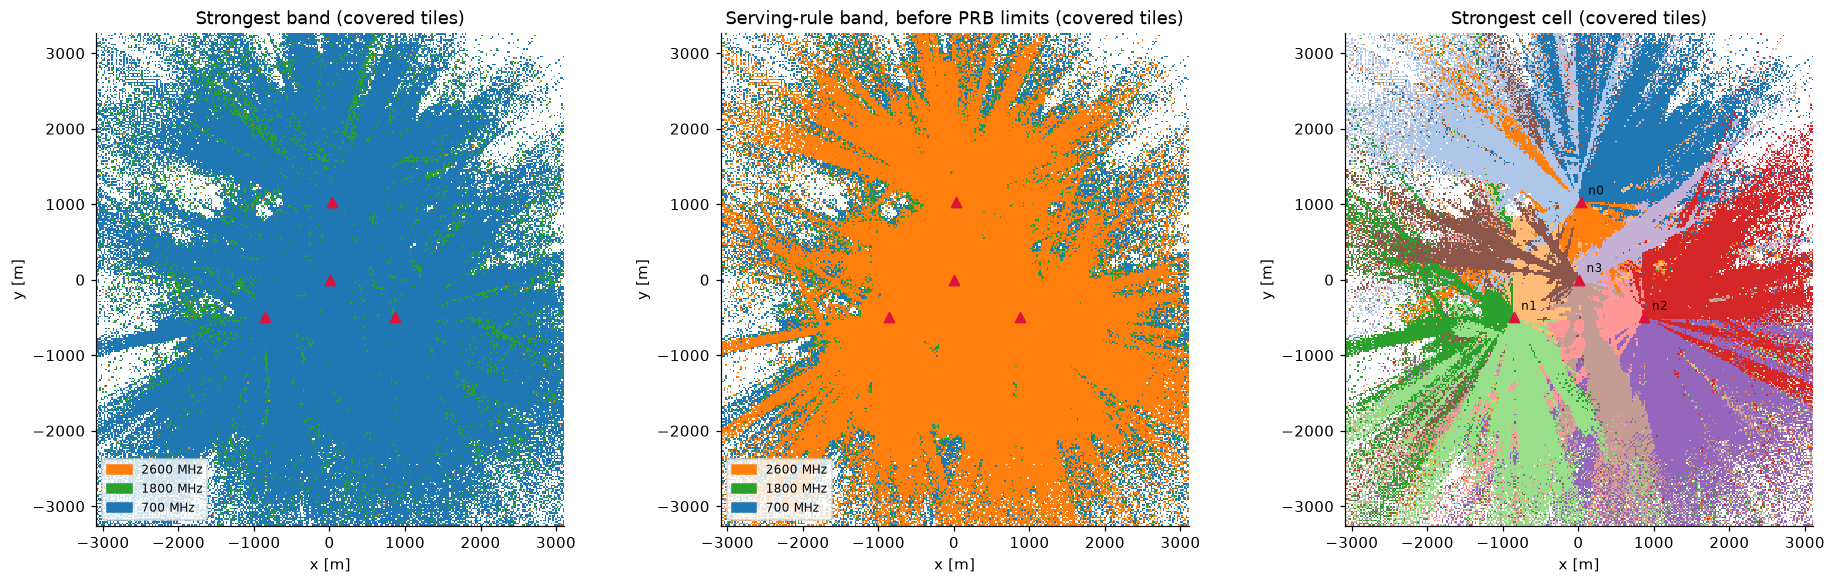

,Band,"Strongest band, share of covered area","Serving-rule band, share of covered area","Strongest band, median distance to nearest node [m]"
0,2600 MHz,0.0032,0.7723,2168.3985
1,1800 MHz,0.0974,0.0676,1913.7387
2,700 MHz,0.8994,0.1601,1530.0167


,Serving band,Share of UE rows
0,2600 MHz,0.2829
1,1800 MHz,0.0540
2,700 MHz,0.0748
3,Not served,0.5882


In [15]:
stacked = capacity.finite(rsrp).reshape(n_band * n_tx, n_rows, n_cols)
strongest = stacked.argmax(axis=0)
reached = np.isfinite(best_overall)
covered = best_overall > hole_dbm
strongest_band = np.where(reached, strongest // n_tx, -1)
strongest_cell = np.where(reached, strongest % n_tx, -1)
rule_band = maps.serving_band(rsrp, spec.band_rank, spec.rsrp_threshold_dbm, spec.min_rsrp_dbm)

band_colours = {low_band: "tab:blue", mid_band: "tab:green", high_band: "tab:orange"}
colours = [band_colours[b] for b in bands]
figure, axes = plt.subplots(1, 3, figsize=(17.0, 5.2), constrained_layout=True)
class_map(axes[0], np.where(covered, strongest_band, -1), [label(b) for b in bands], colours, "Strongest band (covered tiles)")
class_map(axes[1], np.where(covered, rule_band, -1), [label(b) for b in bands], colours, "Serving-rule band, before PRB limits (covered tiles)")
axes[2].imshow(np.where(covered, strongest_cell, np.nan), origin="lower", extent=extent, cmap="tab20", vmin=-0.5, vmax=19.5, interpolation="nearest")
axes[2].scatter(nodes["x"], nodes["y"], marker="^", s=45, color="crimson", zorder=3)
for name, row in nodes.iterrows():
    axes[2].annotate(name, (row.x, row.y), textcoords="offset points", xytext=(5, 5), fontsize=8)
axes[2].set(title="Strongest cell (covered tiles)", xlabel="x [m]", ylabel="y [m]")
axes[2].grid(False)
save_fig(figure, "serving_maps")
plt.show()

serving_area = pd.DataFrame(
    [
        {
            "Band": label(band),
            "Strongest band, share of covered area": (strongest_band[covered] == b).mean(),
            "Serving-rule band, share of covered area": (rule_band[covered] == b).mean(),
            "Strongest band, median distance to nearest node [m]": np.median(node_distance[covered & (strongest_band == b)]) if (covered & (strongest_band == b)).any() else np.nan,
        }
        for b, band in enumerate(bands)
    ]
)
save_table(serving_area, "serving_area_per_band")
display(serving_area)

service = compare.service_summary(served, bands)
serving_mix = pd.DataFrame(
    [{"Serving band": label(band), "Share of UE rows": service[f"share_{band}"]} for band in bands]
    + [{"Serving band": "Not served", "Share of UE rows": service["not_served_share"]}]
)
save_table(serving_mix, "serving_band_mix")
serving_mix

### Key takeaway

By raw signal, 700 MHz is the strongest band on 90 % of the covered area, 1800 MHz on 10 % and 2600 MHz almost
nowhere. The serving rule flips this: with 2600 MHz preferred whenever it clears the threshold, it takes 77 % of
covered area before PRB limits. UE rows are served 28 % on 2600 MHz, 5 % on 1800 MHz and 7 % on 700 MHz, and 59 %
are not served — holes, plus PRB exhaustion. The few covered tiles where 1800 or 2600 MHz is strongest lie
farther from the nodes by median distance than the 700 MHz ones; this table does not show why.

## 7. Coverage Quality Analysis

Thresholds come from `configs/kpi.yaml`: a tile is a **hole** when $RSRP_{\max}(g) \le$ `kpi.hole_dbm`, **weak**
when `kpi.hole_dbm` $< RSRP_{\max}(g) \le$ `kpi.weak_dbm`, and **good** above that.

### 7.1 Coverage Holes

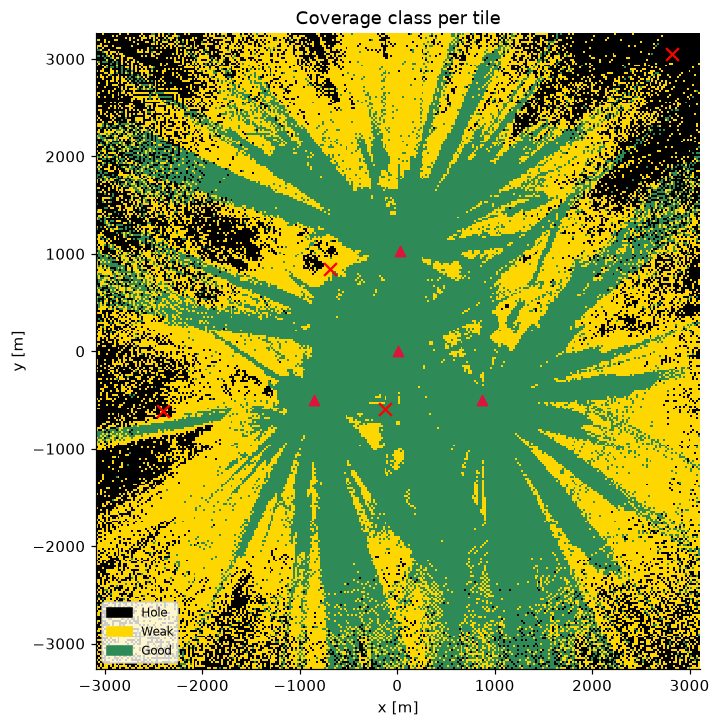

,Property,Value
0,Hole tiles,18598.0000
1,Hole rate (share of grid),0.1840
2,Hole tiles with no path at all,9813.0000
3,Connected hole regions (4-neighbour),3925.0000
4,Share of hole area in the largest region,0.2115
5,Regions of a single tile,2644.0000
6,Hole rate within 1 km of a node,0.0088
7,Hole rate beyond 1 km of a node,0.2337
8,UE rows on hole tiles,0.3334


In [16]:
figure, axis = plt.subplots(figsize=(7.5, 6.5), constrained_layout=True)
class_map(axis, coverage, ["Hole", "Weak", "Good"], ["black", "gold", "seagreen"], "Coverage class per tile")
axis.scatter(hotspots["x"], hotspots["y"], marker="x", s=70, color="red", zorder=4)
save_fig(figure, "coverage_class_map")
plt.show()

holes = coverage == maps.HOLE
components, n_components = ndimage.label(holes)
sizes = np.sort(np.bincount(components.ravel())[1:])[::-1]
hole_summary = pd.DataFrame(
    {
        "Value": {
            "Hole tiles": int(holes.sum()),
            "Hole rate (share of grid)": holes.mean(),
            "Hole tiles with no path at all": int((~reached).sum()),
            "Connected hole regions (4-neighbour)": n_components,
            "Share of hole area in the largest region": sizes[0] / holes.sum() if n_components else np.nan,
            "Regions of a single tile": int((sizes == 1).sum()),
            "Hole rate within 1 km of a node": holes[node_distance <= 1000].mean(),
            "Hole rate beyond 1 km of a node": holes[node_distance > 1000].mean(),
            "UE rows on hole tiles": (holes[ue.tile_row, ue.tile_col]).mean(),
        }
    }
).rename_axis("Property").reset_index()
save_table(hole_summary, "hole_summary")
hole_summary

### Key takeaway

Holes cover 18 % of the grid and are almost entirely an edge effect: under 1 % within 1 km of a node against 23 %
beyond it. Half the hole tiles have no path at all. They are fragmented — 3 925 regions, 2 644 of them single tiles
(scattered speckle in the maps), the largest holding 21 % of hole area; the large contiguous holes sit in the
grid corners, north-east and west. A third of UE rows stand on hole tiles,
so the holes that matter coincide with demand far from the nodes, not with gaps between them.

### 7.2 Weak Coverage

In [17]:
weak = coverage == maps.WEAK
weak_by_band = pd.DataFrame(
    [
        {
            "Strongest band": label(band),
            "Weak tiles": int((weak & (strongest_band == b)).sum()),
            "Share of weak tiles": (strongest_band[weak] == b).mean(),
            "Share of that band's strongest-server area that is weak": (weak[strongest_band == b]).mean(),
        }
        for b, band in enumerate(bands)
    ]
)
weak_summary = pd.DataFrame(
    {
        "Value": {
            "Weak rate (share of grid)": weak.mean(),
            "Weak share of covered tiles": weak[covered].mean(),
            "Median distance to nearest node, weak tiles [m]": np.median(node_distance[weak]),
            "Median distance to nearest node, good tiles [m]": np.median(node_distance[coverage == maps.GOOD]),
            "UE rows on weak tiles": weak[ue.tile_row, ue.tile_col].mean(),
        }
    }
).rename_axis("Property").reset_index()
save_table(weak_by_band, "weak_by_band")
display(weak_summary)
weak_by_band

,Property,Value
0,Weak rate (share of grid),0.4063
1,Weak share of covered tiles,0.4979
2,"Median distance to nearest node, weak tiles [m]",1917.8355
3,"Median distance to nearest node, good tiles [m]",1129.0421
4,UE rows on weak tiles,0.3176


,Strongest band,Weak tiles,Share of weak tiles,Share of that band's strongest-server area that is weak
0,2600 MHz,253,0.0062,0.3074
1,1800 MHz,6204,0.1511,0.5390
2,700 MHz,34604,0.8427,0.4385


### Key takeaway

Weak coverage is the largest class: 41 % of the grid, half of all covered tiles. Weak tiles lie farther from nodes
than good ones (median ≈ 1.9 km against 1.1 km), so they form the ring between good coverage and holes rather than
sector-boundary slivers. 84 % of weak tiles have 700 MHz as their strongest band — the higher bands have already
dropped below it there. Weak tiles hold 32 % of UE rows.

## 8. Coverage Overlap Analysis

The overlap rule is **co-band** (`src/kpi/overlap.py`): within one band the strongest cell serves, and every other
cell of that band with $R > $ `kpi.hole_dbm` and $R \ge R_{serv} -$ `kpi.overlap_margin_db` is an overlapping
neighbour. $N_{ov}(g)$ sums those neighbours over bands; the overlap rate is the share of the grid with $N_{ov} > 0$.

### 8.1 Same-Band Coverage Overlap

In [18]:
n_ov = overlap_neighbors(rsrp, cfg)
per_band_ov = {band: overlap_neighbors(rsrp[[b]], cfg) for b, band in enumerate(bands)}

overlap_table = pd.DataFrame(
    [
        {
            "Layer": label(band),
            "Overlap rate (share of grid)": (per_band_ov[band] > 0).mean(),
            "Overlap share of band-covered tiles": (per_band_ov[band][best_per_band[bands.index(band)] > hole_dbm] > 0).mean(),
            "Mean neighbours, band-covered tiles": per_band_ov[band][best_per_band[bands.index(band)] > hole_dbm].mean(),
        }
        for band in by_frequency
    ]
    + [
        {
            "Layer": "All bands (KPI)",
            "Overlap rate (share of grid)": (n_ov > 0).mean(),
            "Overlap share of band-covered tiles": (n_ov[covered] > 0).mean(),
            "Mean neighbours, band-covered tiles": n_ov[covered].mean(),
        }
    ]
)
save_table(overlap_table, "overlap_per_band")
overlap_table

,Layer,Overlap rate (share of grid),Overlap share of band-covered tiles,"Mean neighbours, band-covered tiles"
0,700 MHz,0.2095,0.2683,0.3487
1,1800 MHz,0.1829,0.2691,0.3482
2,2600 MHz,0.1663,0.2639,0.3342
3,All bands (KPI),0.2689,0.3295,0.8818


### 8.2 Mean Number of Overlapping Neighbors

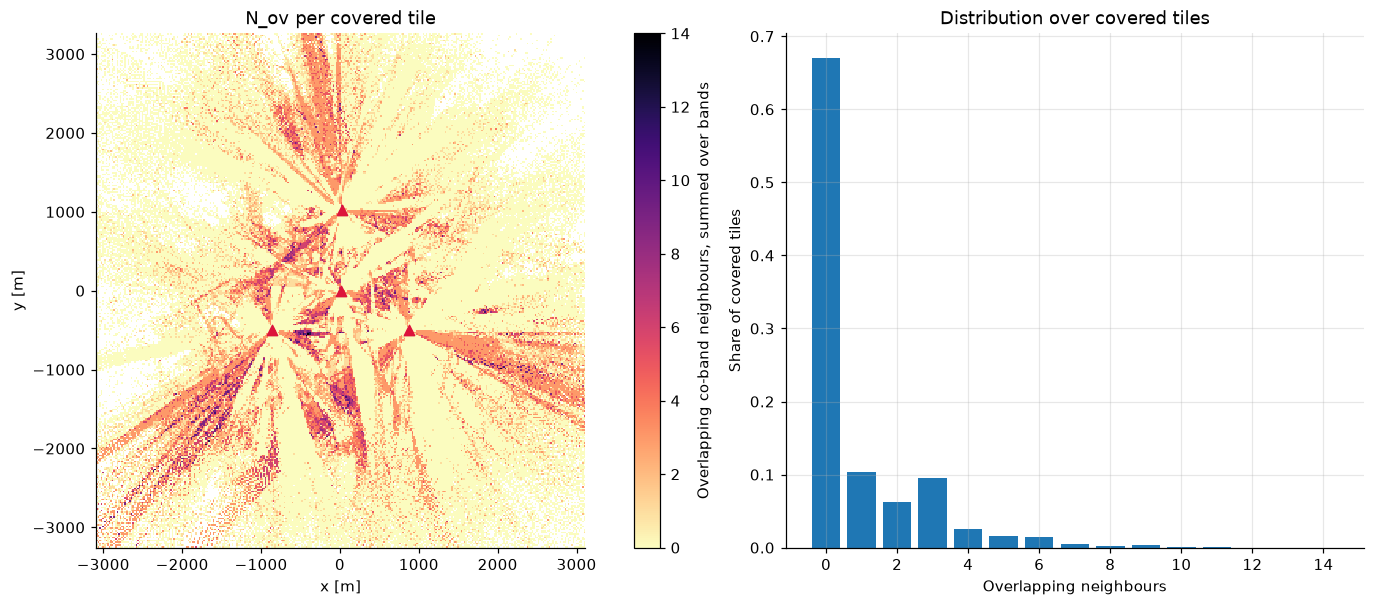

,Property,Value
0,"Mean N_ov, covered tiles",0.8818
1,"Median N_ov, covered tiles",0.0000
2,"P90 N_ov, covered tiles",3.0000
3,Max N_ov,14.0000
4,Share of covered tiles with N_ov >= 3,0.1633
5,"Median distance to nearest node, N_ov >= 3 [m]",1175.3184
6,UE rows on tiles with N_ov > 0,0.2782


In [19]:
figure, axes = plt.subplots(1, 2, figsize=(14.0, 5.4), constrained_layout=True, gridspec_kw={"width_ratios": [1.3, 1]})
image = axes[0].imshow(np.where(covered, n_ov, np.nan), origin="lower", extent=extent, cmap="magma_r", interpolation="nearest")
figure.colorbar(image, ax=axes[0], label="Overlapping co-band neighbours, summed over bands")
axes[0].scatter(nodes["x"], nodes["y"], marker="^", s=45, color="crimson", zorder=3)
axes[0].set(title="N_ov per covered tile", xlabel="x [m]", ylabel="y [m]")
axes[0].grid(False)
counts = np.bincount(n_ov[covered])
axes[1].bar(np.arange(counts.size), counts / covered.sum())
axes[1].set(xlabel="Overlapping neighbours", ylabel="Share of covered tiles", title="Distribution over covered tiles")
save_fig(figure, "overlap_neighbours")
plt.show()

high_overlap = covered & (n_ov >= 3)
neighbour_summary = pd.DataFrame(
    {
        "Value": {
            "Mean N_ov, covered tiles": n_ov[covered].mean(),
            "Median N_ov, covered tiles": np.median(n_ov[covered]),
            "P90 N_ov, covered tiles": np.percentile(n_ov[covered], 90),
            "Max N_ov": int(n_ov.max()),
            "Share of covered tiles with N_ov >= 3": high_overlap.sum() / covered.sum(),
            "Median distance to nearest node, N_ov >= 3 [m]": np.median(node_distance[high_overlap]) if high_overlap.any() else np.nan,
            "UE rows on tiles with N_ov > 0": (n_ov[ue.tile_row, ue.tile_col] > 0).mean(),
        }
    }
).rename_axis("Property").reset_index()
save_table(neighbour_summary, "overlap_neighbour_summary")
neighbour_summary

### Key takeaway

Co-band overlap affects 27 % of the grid and a third of covered tiles, at a similar rate in each band (≈ 26–27 % of
each band's covered area). The distribution is skewed: the median covered tile has no overlapping neighbour and the
mean is 0.88, but 16 % of covered tiles have three or more (up to 14 summed over bands). Heavy overlap sits
closer to nodes (median ≈ 1.2 km) than weak coverage does. 28 % of UE rows are on overlapping tiles.

## 9. Cross-Band Coverage Relationship

### 9.1 Signal Correlation Between Bands

Per-band best RSRP on the tiles every band reaches.

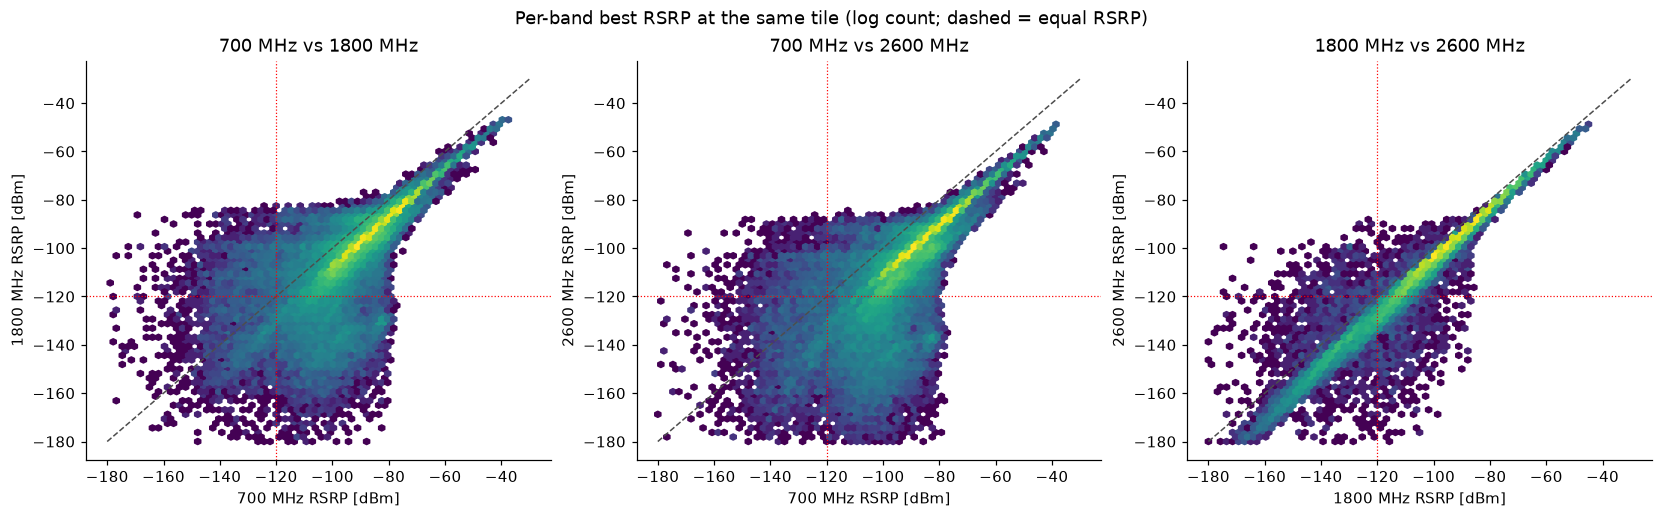

,700 MHz,1800 MHz,2600 MHz
700 MHz,1.000,0.757,0.761
1800 MHz,0.757,1.000,0.973
2600 MHz,0.761,0.973,1.000


,700 MHz,1800 MHz,2600 MHz
700 MHz,1.000,0.870,0.873
1800 MHz,0.870,1.000,0.988
2600 MHz,0.873,0.988,1.000


,Pair,Median gap [dB],Tiles where first is stronger
0,700 MHz minus 1800 MHz,7.6829,0.9087
1,700 MHz minus 2600 MHz,11.0310,0.9500
2,1800 MHz minus 2600 MHz,4.0052,0.9848


In [20]:
common = np.all(np.isfinite(best_per_band), axis=0)
paired = pd.DataFrame({label(band): best_per_band[bands.index(band)][common] for band in by_frequency})

pairs = list(combinations(by_frequency, 2))
figure, axes = plt.subplots(1, len(pairs), figsize=(5.0 * len(pairs), 4.6), constrained_layout=True)
for axis, (a, b) in zip(axes, pairs):
    axis.hexbin(paired[label(a)], paired[label(b)], gridsize=70, bins="log", mincnt=1, extent=(-180, -30, -180, -30))
    axis.plot([-180, -30], [-180, -30], color="0.3", lw=1, ls="--")
    axis.axhline(hole_dbm, color="red", lw=0.8, ls=":")
    axis.axvline(hole_dbm, color="red", lw=0.8, ls=":")
    axis.set(xlabel=f"{label(a)} RSRP [dBm]", ylabel=f"{label(b)} RSRP [dBm]", title=f"{label(a)} vs {label(b)}")
    axis.grid(False)
figure.suptitle("Per-band best RSRP at the same tile (log count; dashed = equal RSRP)")
save_fig(figure, "cross_band_scatter")
plt.show()

correlation = paired.corr(method="pearson").round(3)
spearman = paired.corr(method="spearman").round(3)
gaps = pd.DataFrame(
    [
        {"Pair": f"{label(a)} minus {label(b)}", "Median gap [dB]": (paired[label(a)] - paired[label(b)]).median(),
         "Tiles where first is stronger": (paired[label(a)] > paired[label(b)]).mean()}
        for a, b in pairs
    ]
)
save_table(correlation.reset_index(names="Band"), "cross_band_correlation")
display(correlation, spearman)
gaps

### Key takeaway

1800 and 2600 MHz are nearly interchangeable (Pearson 0.97, Spearman 0.99; 1800 is ≈ 4 dB stronger on 98 % of
tiles). 700 MHz is correlated with both but less tightly (≈ 0.76 / 0.87) and is 8–11 dB stronger on over 90 % of
tiles. When one layer is weak the others usually are too; 700 MHz is the only layer that meaningfully compensates.

### 9.2 Band Complementarity

A band is *strong* on a tile when its best cell exceeds `kpi.weak_dbm` (good coverage). Tiles are grouped by which
bands are strong; tiles no band covers above `kpi.hole_dbm` form their own group.

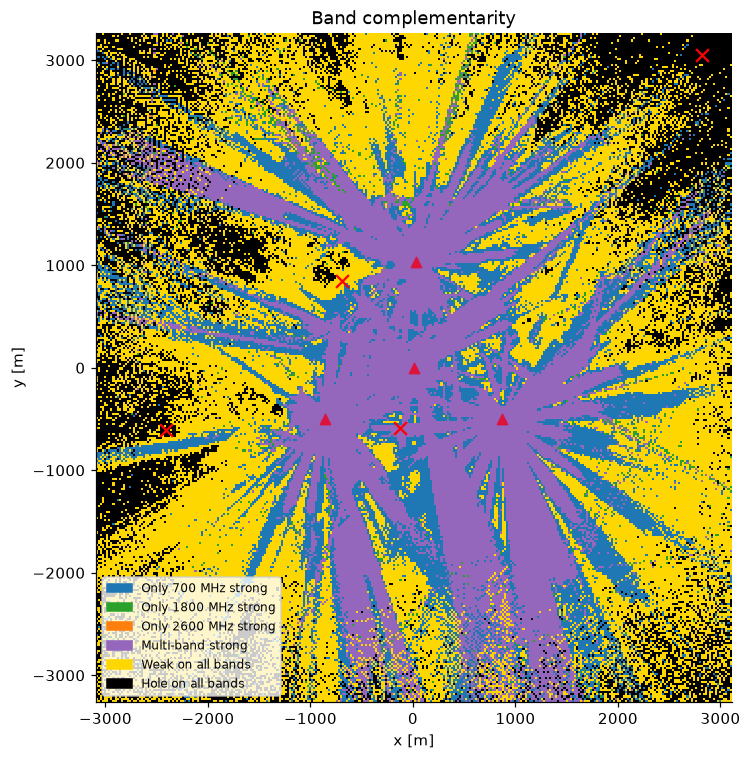

,Group,Share of area,Share of UE rows,Share of peak PRB demand
0,Only 700 MHz strong,1.7027e-01,0.1539,0.0509
1,Only 1800 MHz strong,1.0360e-02,0.0031,0.0008
2,Only 2600 MHz strong,4.9476e-05,0.0000,0.0000
3,Multi-band strong,2.2899e-01,0.1920,0.0252
4,Weak on all bands,4.0630e-01,0.3176,0.9232
5,Hole on all bands,1.8403e-01,0.3334,0.0000


In [21]:
strong = best_per_band > weak_dbm
n_strong = strong.sum(axis=0)
low_i, mid_i, high_i = (bands.index(b) for b in (low_band, mid_band, high_band))
complement_names = [
    f"Only {label(low_band)} strong",
    f"Only {label(mid_band)} strong",
    f"Only {label(high_band)} strong",
    "Multi-band strong",
    "Weak on all bands",
    "Hole on all bands",
]
complement = np.select(
    [
        best_overall <= hole_dbm,
        n_strong == 0,
        n_strong >= 2,
        strong[low_i],
        strong[mid_i],
        strong[high_i],
    ],
    [5, 4, 3, 0, 1, 2],
)
figure, axis = plt.subplots(figsize=(8.0, 6.8), constrained_layout=True)
class_map(axis, complement, complement_names, ["tab:blue", "tab:green", "tab:orange", "tab:purple", "gold", "black"], "Band complementarity")
axis.scatter(hotspots["x"], hotspots["y"], marker="x", s=70, color="red", zorder=4)
save_fig(figure, "band_complementarity")
plt.show()

total_demand = peak_prb.sum()
complementarity = pd.DataFrame(
    [
        {
            "Group": name,
            "Share of area": (complement == index).mean(),
            "Share of UE rows": (complement[ue.tile_row, ue.tile_col] == index).mean(),
            "Share of peak PRB demand": peak_prb[complement == index].sum() / total_demand,
        }
        for index, name in enumerate(complement_names)
    ]
)
save_table(complementarity, "band_complementarity")
complementarity

### Key takeaway

18 % of the grid is a hole on every band and 41 % is weak on every band; 23 % is strong on two or more bands, and
17 % is strong on 700 MHz alone. Strong-on-1800-only is 1 % and strong-on-2600-only practically absent. Complementarity
therefore runs one way: the low band extends coverage, the higher bands only duplicate it. The tiles where all bands
are weak carry 92 % of the measured peak PRB demand — the region where coordinated tilt could matter most.

## 10. Spatial Analysis

### 10.1 UE / Demand Distribution

Hotspot centres are drawn at least `simulation.density.min_hotspot_distance_m` apart.

,rotation_rad,sigma_major_m,sigma_minor_m,x,y,nearest_node,distance_to_nearest_node_m,best_rsrp_at_centre_dbm,ue_rows
0,0.7059,180.7055,86.9714,-690.4170,843.4472,n0,742.7416,-100.3469,1675
1,2.8020,134.1238,116.4252,-126.0186,-588.5538,n3,603.4822,-79.4574,1585
2,2.9900,80.4893,64.7139,-2405.7218,-608.5134,n1,1550.9041,-122.2999,1730
3,2.9621,193.4152,87.4539,2819.4101,3052.7564,n0,3447.8376,-inf,1868


,Property,Value
0,Configured minimum distance [m],500.0000
1,Closest pair of hotspot centres [m],1539.2116
2,Farthest pair of hotspot centres [m],6380.1959
3,Background UE rows,3208.0000


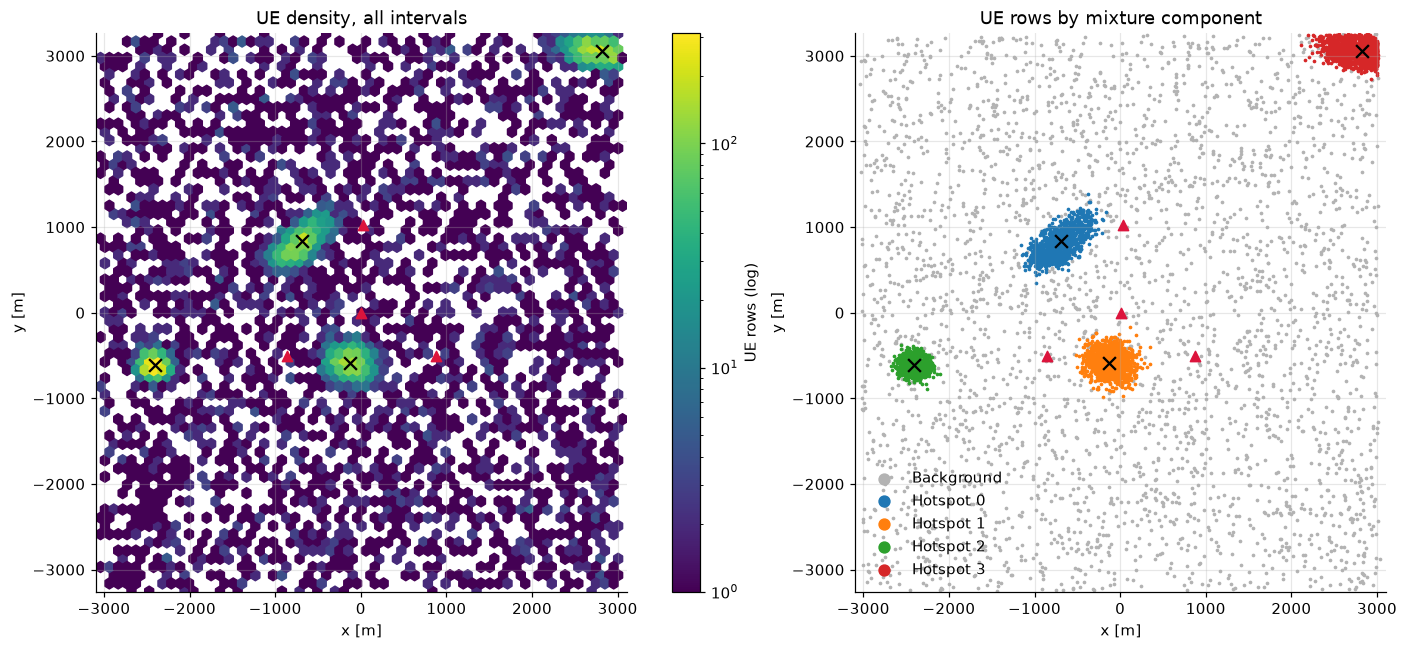

In [22]:
hotspot_table = hotspots.assign(
    nearest_node=[nodes.index[np.argmin(np.hypot(nodes.x - h.x, nodes.y - h.y))] for h in hotspots.itertuples()],
    distance_to_nearest_node_m=[np.min(np.hypot(nodes.x - h.x, nodes.y - h.y)) for h in hotspots.itertuples()],
    best_rsrp_at_centre_dbm=[
        best_overall[min(int((h.y - extent[2]) // tile_m), n_rows - 1), min(int((h.x - extent[0]) // tile_m), n_cols - 1)]
        for h in hotspots.itertuples()
    ],
    ue_rows=[int((ue.component == i).sum()) for i in range(len(hotspots))],
)
spacing = pd.DataFrame(
    {
        "Value": {
            "Configured minimum distance [m]": float(cfg.simulation.density.min_hotspot_distance_m),
            "Closest pair of hotspot centres [m]": pdist(hotspots[["x", "y"]]).min(),
            "Farthest pair of hotspot centres [m]": pdist(hotspots[["x", "y"]]).max(),
            "Background UE rows": int((ue.component == -1).sum()),
        }
    }
).rename_axis("Property").reset_index()
save_table(hotspot_table, "hotspots")
display(hotspot_table, spacing)

figure, axes = plt.subplots(1, 2, figsize=(14.0, 5.8), constrained_layout=True)
hb = axes[0].hexbin(ue.x, ue.y, gridsize=60, bins="log", mincnt=1, extent=extent)
figure.colorbar(hb, ax=axes[0], label="UE rows (log)")
axes[0].set(title="UE density, all intervals")
background = ue.component == -1
axes[1].scatter(ue.x[background], ue.y[background], s=2, color="0.7", label="Background")
for i in range(len(hotspots)):
    part = ue.component == i
    axes[1].scatter(ue.x[part], ue.y[part], s=2, label=f"Hotspot {i}")
axes[1].legend(markerscale=5)
axes[1].set(title="UE rows by mixture component")
for axis in axes:
    axis.scatter(nodes["x"], nodes["y"], marker="^", s=45, color="crimson", zorder=3)
    axis.scatter(hotspots["x"], hotspots["y"], marker="x", s=70, color="black", zorder=4)
    axis.set(xlim=extent[:2], ylim=extent[2:], xlabel="x [m]", ylabel="y [m]", aspect="equal")
save_fig(figure, "ue_distribution")
plt.show()

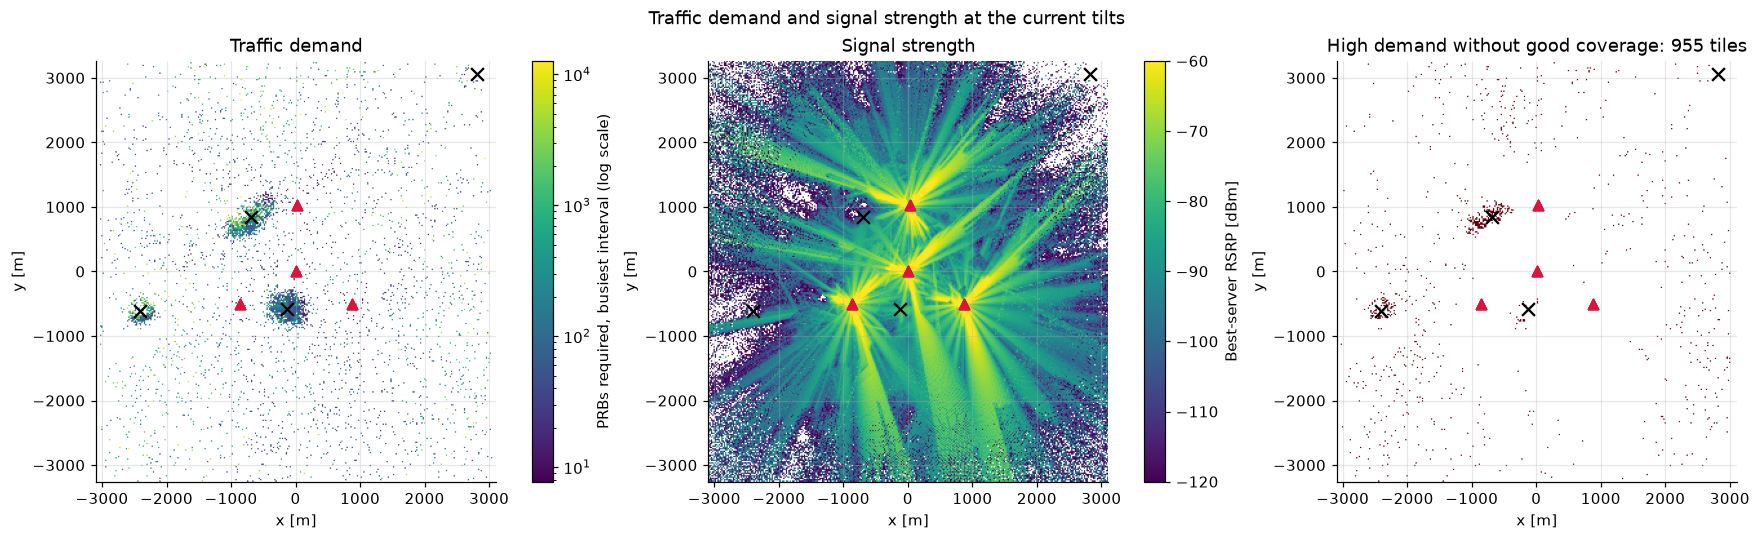

,Coverage class,Tiles,Share of area,Peak PRB demand,Share of demand
0,hole,18598,0.1840,0.0000e+00,0.0000
1,weak,41061,0.4063,2.3628e+06,0.9232
2,good,41401,0.4097,1.9669e+05,0.0768


In [23]:
figure = plots.demand_signal_maps(rsrp, peak_prb, radio_map, cfg, cells=cells, hotspots=hotspots)
figure.suptitle("Traffic demand and signal strength at the current tilts")
save_fig(figure, "demand_vs_coverage")
plt.show()

area_vs_demand = readable(maps.coverage_table(rsrp, peak_prb, cfg))
save_table(area_vs_demand, "coverage_by_area_and_demand")
area_vs_demand

### Key takeaway

The four hotspots are 1.5–6.4 km apart, so the ≥ 500 m spacing holds with margin. Only two of them are near a node
(hotspots 0 and 1, 0.6–0.7 km, centre RSRP −100 and −79 dBm). Hotspot 2 is 1.6 km out at −122 dBm, and hotspot 3
is 3.4 km from the nearest node with no path at all: its 1 868 UE rows fall in a hole no tilt can reach.
Weighted by area the grid is 18 % hole, 41 % weak and 41 % good; weighted by demand, 92 % sits on weak tiles and
8 % on good ones. The hole row shows zero demand only because a UE with no candidate cell-band gets no PRB count
(`capacity.prb_by_interval`) — demand in holes is invisible in this measure, not absent.

### 10.2 Signal Strength vs UE Density

Occupied tiles (at least one UE row) grouped by how many UE rows they hold over the week, against the per-band best RSRP.

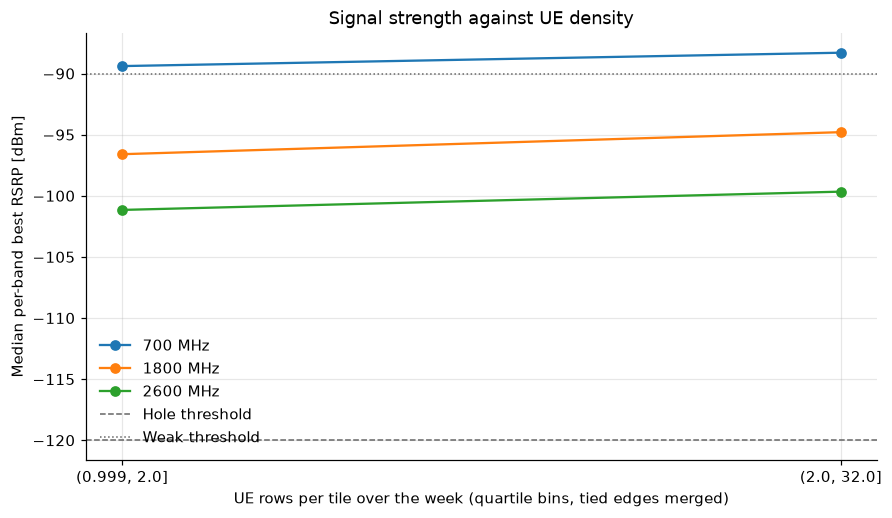

,Median 700 MHz [dBm],Median 1800 MHz [dBm],Median 2600 MHz [dBm],Share covered,Tiles
UE rows per tile,,,,,
"(0.999, 2.0]",-89.3902,-96.5985,-101.1570,0.8051,4213
"(2.0, 32.0]",-88.2955,-94.7949,-99.6619,0.6218,928


In [24]:
ue_per_tile = np.zeros((n_rows, n_cols))
np.add.at(ue_per_tile, (ue.tile_row, ue.tile_col), 1)
occupied = ue_per_tile > 0
density_bins = pd.qcut(ue_per_tile[occupied], 4, duplicates="drop")
signal_vs_density = pd.DataFrame(
    {"UE rows per tile": density_bins}
    | {label(band): best_per_band[bands.index(band)][occupied] for band in by_frequency}
    | {"Covered": covered[occupied]}
)
signal_vs_density = signal_vs_density.replace(-np.inf, np.nan)
density_table = signal_vs_density.groupby("UE rows per tile", observed=True).agg(
    **{f"Median {label(b)} [dBm]": (label(b), "median") for b in by_frequency},
    **{"Share covered": ("Covered", "mean"), "Tiles": ("Covered", "size")},
)
save_table(density_table.reset_index().astype({"UE rows per tile": str}), "signal_vs_ue_density")

figure, axis = plt.subplots(figsize=(8.0, 4.6), constrained_layout=True)
for band in by_frequency:
    axis.plot(density_table.index.astype(str), density_table[f"Median {label(band)} [dBm]"], marker="o", label=label(band))
axis.axhline(hole_dbm, color="0.4", ls="--", lw=1, label="Hole threshold")
axis.axhline(weak_dbm, color="0.4", ls=":", lw=1, label="Weak threshold")
axis.set(xlabel="UE rows per tile over the week (quartile bins, tied edges merged)", ylabel="Median per-band best RSRP [dBm]", title="Signal strength against UE density")
axis.legend()
save_fig(figure, "signal_vs_ue_density")
plt.show()
density_table

### Key takeaway

Most occupied tiles hold one or two UE rows over the week, so only two density bins are distinct. Busier tiles have
a slightly stronger median signal on every band (≈ 1–2 dB) but are *less* often covered (62 % against 81 %), because
the busiest tiles include the hotspot that has no path. Coverage does not follow demand.

### 10.3 MDT Reports vs All UE Positions

The MDT keeps only the UE rows served at the current tilts (`src/simulation/mdt.py`). The optimizer scores
the served ratio and $J_{load}$ on it; evaluation re-scores on every UE row. What the MDT leaves out is
invisible to the search, so this compares the two populations in time, space, mixture component and
coverage.

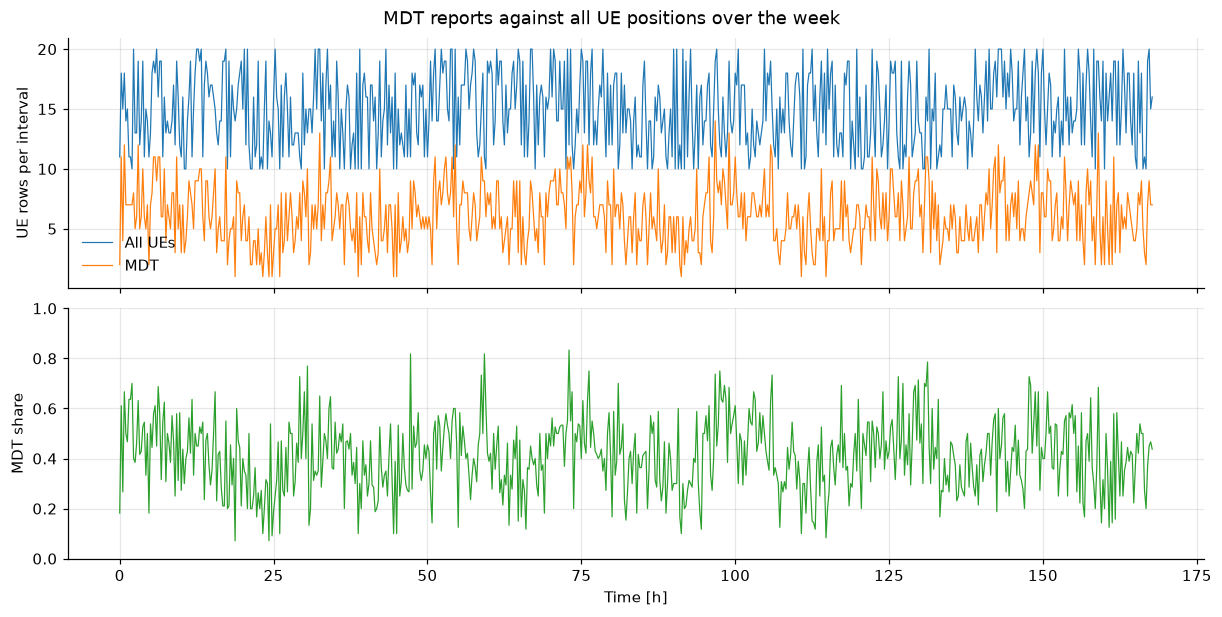

,Property,Value
0,UE rows,10066
1,MDT rows,4145
2,MDT share of UE rows,0.4118
3,Unserved UE rows,5921
4,Unserved UE rows with no path to any cell,2533
5,Intervals with no MDT report,0
6,"MDT share per interval, min-max",0.07-0.83
7,"Distinct tiles, all UEs",5141
8,"Distinct tiles, MDT",2563


In [25]:
per_interval = pd.DataFrame(
    {"All UEs": ue.groupby("t_index").size(), "MDT": mdt.groupby("t_index").size()}
).fillna(0)
share = per_interval["MDT"] / per_interval["All UEs"]
hours = np.asarray(manifest["time"]["t_s"])[per_interval.index] / 3600.0

figure, axes = plt.subplots(2, 1, figsize=(11.0, 5.5), sharex=True, constrained_layout=True)
axes[0].plot(hours, per_interval["All UEs"], lw=0.8, label="All UEs")
axes[0].plot(hours, per_interval["MDT"], lw=0.8, label="MDT")
axes[0].set(ylabel="UE rows per interval")
axes[0].legend()
axes[1].plot(hours, share, lw=0.8, color="tab:green")
axes[1].set(xlabel="Time [h]", ylabel="MDT share", ylim=(0, 1))
figure.suptitle("MDT reports against all UE positions over the week")
save_fig(figure, "mdt_over_time")
plt.show()

mdt_overview = pd.DataFrame(
    {
        "Value": {
            "UE rows": len(ue),
            "MDT rows": len(mdt),
            "MDT share of UE rows": len(mdt) / len(ue),
            "Unserved UE rows": int((~in_mdt).sum()),
            "Unserved UE rows with no path to any cell": int(
                (~np.isfinite(best_overall[ue.tile_row, ue.tile_col])).sum()
            ),
            "Intervals with no MDT report": int((per_interval["MDT"] == 0).sum()),
            "MDT share per interval, min-max": f"{share.min():.2f}-{share.max():.2f}",
            "Distinct tiles, all UEs": ue[["tile_row", "tile_col"]].drop_duplicates().shape[0],
            "Distinct tiles, MDT": mdt[["tile_row", "tile_col"]].drop_duplicates().shape[0],
        }
    }
).rename_axis("Property").reset_index()
save_table(mdt_overview, "mdt_overview")
mdt_overview

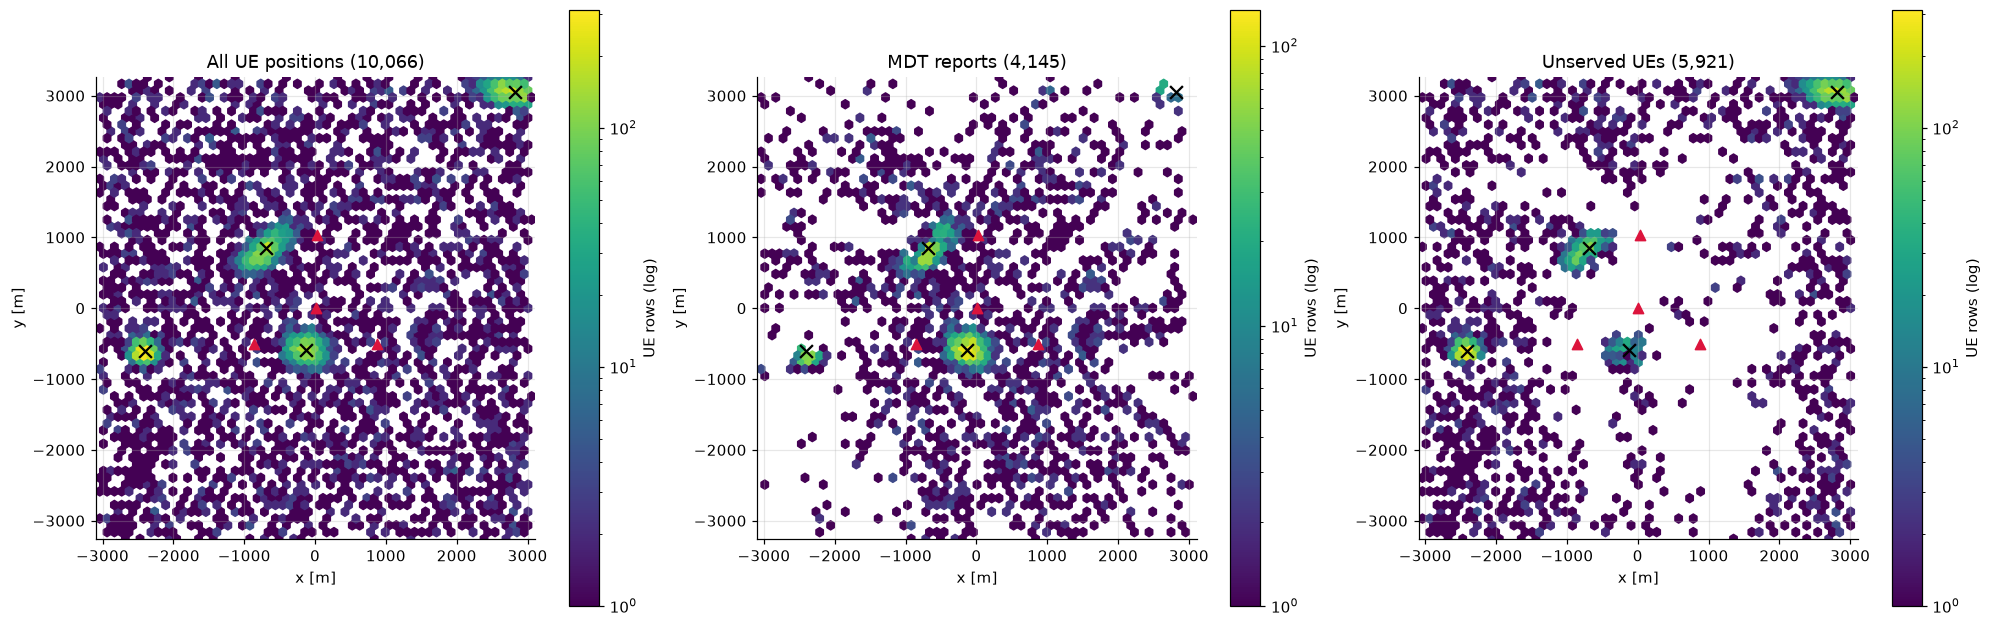

,Component,UE rows,Share in MDT
0,Background,3208,0.5305
1,Hotspot 0,1675,0.4621
2,Hotspot 3,1868,0.0300
3,Hotspot 1,1585,0.8423
4,Hotspot 2,1730,0.1607


,Coverage class of the UE tile,UE rows,Share of all UE rows,Share of MDT rows,Share in MDT
0,Hole,3356,0.3334,0.0000,0.0000
1,Weak,3197,0.3176,0.2263,0.2934
2,Good,3513,0.3490,0.7737,0.9129


In [26]:
populations = {"All UE positions": ue, "MDT reports": mdt, "Unserved UEs": ue[~in_mdt]}
figure, axes = plt.subplots(1, 3, figsize=(18.0, 5.6), constrained_layout=True)
for axis, (title, frame) in zip(axes, populations.items()):
    hb = axis.hexbin(frame.x, frame.y, gridsize=60, bins="log", mincnt=1, extent=extent)
    figure.colorbar(hb, ax=axis, label="UE rows (log)")
    axis.scatter(nodes["x"], nodes["y"], marker="^", s=45, color="crimson", zorder=3)
    axis.scatter(hotspots["x"], hotspots["y"], marker="x", s=70, color="black", zorder=4)
    axis.set(title=f"{title} ({len(frame):,})", xlim=extent[:2], ylim=extent[2:],
             xlabel="x [m]", ylabel="y [m]", aspect="equal")
save_fig(figure, "mdt_vs_ue_positions")
plt.show()

component_names = {-1: "Background", **{i: f"Hotspot {i}" for i in range(len(hotspots))}}
by_component = (
    pd.DataFrame({"Component": ue["component"].map(component_names), "In MDT": in_mdt})
    .groupby("Component", sort=False)["In MDT"]
    .agg(["size", "mean"])
    .rename(columns={"size": "UE rows", "mean": "Share in MDT"})
    .reset_index()
)
ue_class = coverage[ue.tile_row, ue.tile_col]
by_coverage = pd.DataFrame(
    [
        {
            "Coverage class of the UE tile": name.capitalize(),
            "UE rows": int((ue_class == k).sum()),
            "Share of all UE rows": (ue_class == k).mean(),
            "Share of MDT rows": (ue_class[in_mdt] == k).mean(),
            "Share in MDT": in_mdt[ue_class == k].mean() if (ue_class == k).any() else np.nan,
        }
        for k, name in enumerate(maps.COVERAGE_CLASSES)
    ]
)
save_table(by_component, "mdt_share_by_component")
save_table(by_coverage, "mdt_share_by_coverage")
display(by_component)
by_coverage

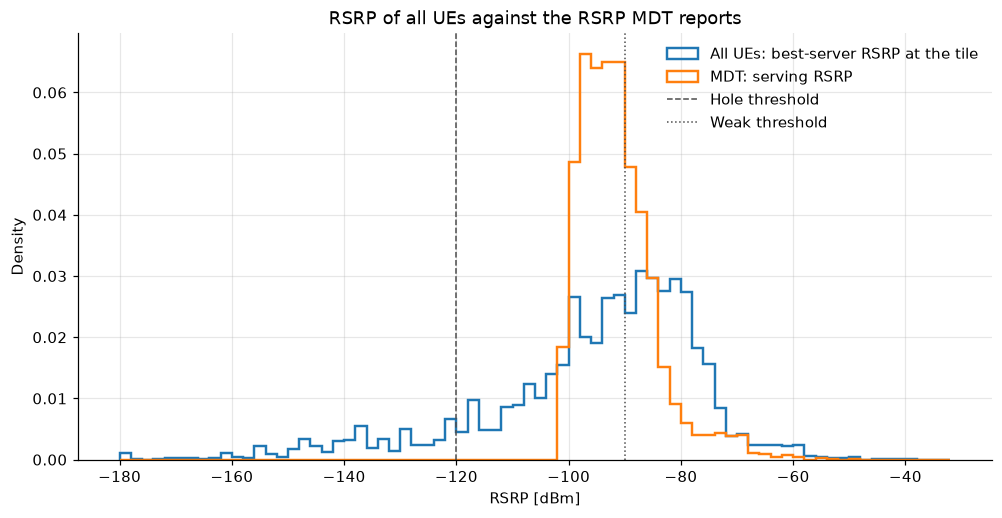

,Population,Rows,P5 [dBm],Median [dBm],P95 [dBm]
0,"All UEs, best-server RSRP (reached tiles)",7533,-136.7211,-91.1647,-72.8258
1,"MDT, serving RSRP",4145,-99.6440,-92.4560,-78.4788


In [27]:
ue_best = best_overall[ue.tile_row, ue.tile_col]
reached_ue = ue_best[np.isfinite(ue_best)]
figure, axis = plt.subplots(figsize=(9.0, 4.6), constrained_layout=True)
edges = np.arange(-180, -30, 2)
axis.hist(reached_ue, bins=edges, histtype="step", lw=1.6, density=True,
          label="All UEs: best-server RSRP at the tile")
axis.hist(mdt["rsrp_dbm"], bins=edges, histtype="step", lw=1.6, density=True, label="MDT: serving RSRP")
axis.axvline(hole_dbm, color="0.3", ls="--", lw=1, label="Hole threshold")
axis.axvline(weak_dbm, color="0.3", ls=":", lw=1, label="Weak threshold")
axis.set(xlabel="RSRP [dBm]", ylabel="Density", title="RSRP of all UEs against the RSRP MDT reports")
axis.legend()
save_fig(figure, "mdt_rsrp_vs_ue_rsrp")
plt.show()


def rsrp_row(population, values):
    """Count and percentiles of one RSRP sample."""
    return {"Population": population, "Rows": len(values), "P5 [dBm]": np.percentile(values, 5),
            "Median [dBm]": np.median(values), "P95 [dBm]": np.percentile(values, 95)}


rsrp_compare = pd.DataFrame(
    [
        rsrp_row("All UEs, best-server RSRP (reached tiles)", reached_ue),
        rsrp_row("MDT, serving RSRP", mdt["rsrp_dbm"].to_numpy()),
    ]
)
save_table(rsrp_compare, "mdt_rsrp_statistics")
rsrp_compare

### Key takeaway

The MDT holds 4 145 of 10 066 UE rows (41 %) on 2 563 of 5 141 occupied tiles. Every interval has at least one
report, but the MDT share per interval swings from 7 % to 83 %, so the load the search sees is not a fixed fraction
of the true load. The MDT is strongly biased towards good coverage: no MDT row is on a hole tile (a third of all
UE rows are), 77 % are on good tiles against 35 % of all UE rows, and 91 % of UEs on good tiles report against 29 %
on weak tiles. By component, hotspot 1 (near node n3) is 84 % represented, the background 53 %, hotspot 0 46 %,
hotspot 2 16 % and hotspot 3 (no path) 3 %. Of the 5 921 unserved rows, 2 533 have no path to any cell; the rest
are below the hole threshold or blocked by PRB limits. MDT serving RSRP has a median of −92 dBm, close to the
best-server median of all UEs (−91 dBm), but its 5th percentile is −100 dBm against −137 dBm: the weak tail is
exactly what the MDT drops.

## 11. Antenna Configuration Analysis

### 11.1 Tilt vs Coverage

In [28]:
strongest_area = pd.DataFrame(
    [
        {"cell": cell, "band": band, "Strongest-server tiles, covered": int((covered & (strongest_band == b) & (strongest_cell == t)).sum())}
        for b, band in enumerate(bands) for t, cell in enumerate(tx_names)
    ]
)
load = compare.cell_band_load(served, bands, tx_names, spec.max_prb)
cell_band = (
    pd.DataFrame([{"cell": c, "band": b, "tilt_deg": tilt[bi, ti]} for bi, b in enumerate(bands) for ti, c in enumerate(tx_names)])
    .merge(cells[["cell", "node", "z", "azimuth_deg"]], on="cell")
    .merge(strongest_area, on=["cell", "band"])
    .merge(load[["cell", "band", "served_reports", "peak_utilisation", "median_sinr_db"]], on=["cell", "band"])
)
save_table(cell_band, "cell_band_configuration")
cell_band.pivot_table(index=["node", "cell", "azimuth_deg"], columns="band", values=["Strongest-server tiles, covered", "served_reports", "peak_utilisation"])

Strongest-server tiles, covered                 \
band                                            b1800 b2600     b700   
node cell azimuth_deg                                                  
n0   n0c0 45.0                                  976.0  35.0   9343.0   
     n0c1 165.0                                1166.0  43.0   8417.0   
     n0c2 285.0                                 740.0  10.0   2597.0   
n1   n1c0 45.0                                  258.0   4.0   2340.0   
     n1c1 165.0                                 754.0  33.0   5176.0   
     n1c2 285.0                                 694.0  20.0   9694.0   
n2   n2c0 45.0                                 1128.0  44.0   8320.0   
     n2c1 165.0                                 391.0  14.0   2973.0   
     n2c2 285.0                                 606.0  13.0  11138.0   
n3   n3c0 45.0                                  425.0  17.0   3223.0   
     n3c1 165.0                                 597.0  17.0   5236.0   
     n3c2 285.0                                 299.0  11.0   5710.0   

                      peak_utilisation                 served_reports         \
band                             b1800   b2600    b700          b1800  b2600   
node cell azimuth_deg                                                          
n0   n0c0 45.0                  0.8511  0.9975  0.9972           14.0  114.0   
     n0c1 165.0                 0.9970  0.9923  0.9881           61.0  241.0   
     n0c2 285.0                 0.9180  0.9882  0.9297           23.0   78.0   
n1   n1c0 45.0                  0.9958  0.9945  0.9742          105.0  417.0   
     n1c1 165.0                 0.9511  0.9870  0.9839           46.0  128.0   
     n1c2 285.0                 0.9338  0.9872  0.9483           22.0  198.0   
n2   n2c0 45.0                  0.9992  0.9656  0.9994           27.0  135.0   
     n2c1 165.0                 0.9676  0.9990  0.9939           88.0  596.0   
     n2c2 285.0                 0.9848  0.9901  0.9960           28.0  190.0   
n3   n3c0 45.0                  0.8374  0.9661  0.9942            8.0   46.0   
     n3c1 165.0                 0.9978  0.9941  0.9976           64.0  176.0   
     n3c2 285.0                 0.9923  0.9826  0.9951           58.0  529.0   

                              
band                    b700  
node cell azimuth_deg         
n0   n0c0 45.0          80.0  
     n0c1 165.0         65.0  
     n0c2 285.0         17.0  
n1   n1c0 45.0          92.0  
     n1c1 165.0        184.0  
     n1c2 285.0         27.0  
n2   n2c0 45.0          46.0  
     n2c1 165.0         19.0  
     n2c2 285.0         42.0  
n3   n3c0 45.0          26.0  
     n3c1 165.0        105.0  
     n3c2 285.0         50.0

**Important note.** Observed associations between tilt and coverage are not causal effects: tilt interacts with mast
height, azimuth, the propagation environment, neighbouring cells and frequency. In this dataset the question cannot
even be asked observationally — see 11.2.

### 11.2 Tilt Configuration Across Bands

,Property,Value
0,"Distinct tilt values, all cell-bands",1
1,Nodes where all bands share one tilt,4
2,Distinct mast heights [m],20
3,Distinct azimuths [°],"45, 165, 285"


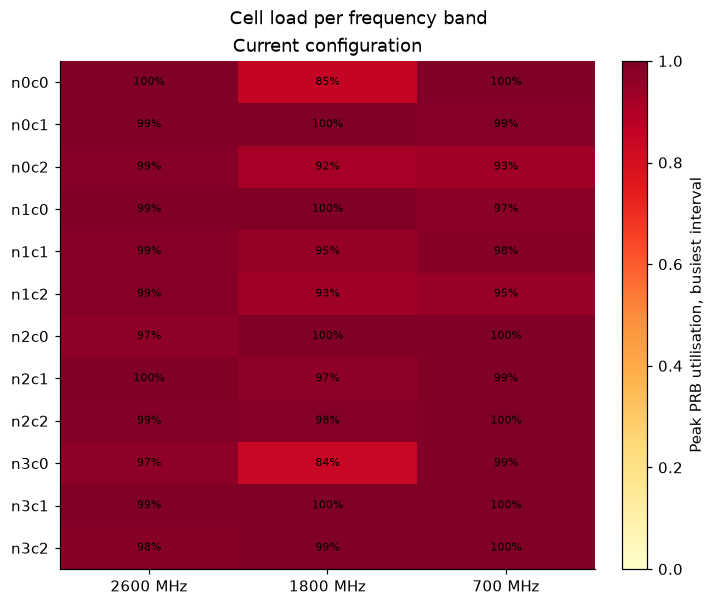

In [29]:
config_summary = pd.DataFrame(
    {
        "Value": {
            "Distinct tilt values, all cell-bands": np.unique(tilt).size,
            "Nodes where all bands share one tilt": int(sum(np.unique(tilt[:, cells.node == n]).size == 1 for n in nodes.index)),
            "Distinct mast heights [m]": ", ".join(f"{z:g}" for z in np.unique(cells.z)),
            "Distinct azimuths [°]": ", ".join(f"{a:g}" for a in np.unique(cells.azimuth_deg)),
        }
    }
).rename_axis("Property").reset_index()
display(config_summary)

figure = plots.utilisation_heatmaps({"incumbent": load})
save_fig(figure, "cell_band_utilisation")
plt.show()

### Key takeaway

All four nodes use a single tilt on all three bands, with identical mast heights (20 m) and the same azimuth fan
(45°, 165°, 285°). Band-specific configuration is absent even though the bands differ by 8–11 dB in median signal.
Load, not area, is the pressure point: almost every cell-band peaks above 90 % PRB utilisation, and 2600 MHz carries
most served UEs despite being the strongest band on almost no tiles. Strongest-server area is very uneven between
cells of the same node (e.g. n2c2 against n2c1 on 700 MHz); with tilt identical everywhere, that difference
cannot come from tilt.

## 12. KPI Summary

The current network measured with the project's KPIs (`src/kpi`) and the two objective terms
(`src/optim/objective.py`, ADR 0006). The template's *Band Priority Score* has no implementation in this project;
band preference enters through the serving rule behind the served ratio and $J_{load}$.

In [30]:
kpis = evaluate_kpis(rsrp, sinr, bands, ue, cfg)
interpretation = {
    "hole_rate": "Share of tiles with no cell-band above kpi.hole_dbm",
    "overlap_rate": "Share of tiles with at least one co-band neighbour within kpi.overlap_margin_db",
    "served_ratio": "Share of UE rows admitted by the serving rule under PRB limits",
    "weak_rate": "Share of tiles covered, but at or below kpi.weak_dbm",
    "edge_rsrp_dbm": "5th percentile of best RSRP over covered tiles; read beside the hole rate",
    "j_radio": "Coverage utility with an overlap penalty, in [0, 1]",
    "j_load": "Load utility from the CVaR of PRB utilisation above rho_0, in [0, 1]",
}
kpi_table = pd.DataFrame(
    [
        {"KPI": label(name), "Value": getattr(kpis, name), "Direction": "maximise" if name in MAXIMISED else "minimise", "Interpretation": interpretation[name]}
        for name in (*KPI_NAMES, *OBJECTIVE_NAMES)
    ]
    + [{"KPI": "Mean overlap neighbours", "Value": n_ov[covered].mean(), "Direction": "minimise", "Interpretation": "Mean N_ov over covered tiles"}]
)
save_table(kpi_table, "kpi_summary")
kpi_table

,KPI,Value,Direction,Interpretation
0,Coverage hole rate,0.1840,minimise,Share of tiles with no cell-band above kpi.hol...
1,Co-band overlap rate,0.2689,minimise,Share of tiles with at least one co-band neigh...
2,Served UE ratio,0.4118,maximise,Share of UE rows admitted by the serving rule ...
3,Weak coverage rate,0.4063,minimise,"Share of tiles covered, but at or below kpi.we..."
4,Cell-edge RSRP,-112.2728,maximise,5th percentile of best RSRP over covered tiles...
5,Radio utility J_radio,0.5568,maximise,"Coverage utility with an overlap penalty, in [..."
6,Load utility J_load,0.8359,maximise,Load utility from the CVaR of PRB utilisation ...
7,Mean overlap neighbours,0.8818,minimise,Mean N_ov over covered tiles


## 13. Key Findings

Values are from scenario `scn_7d938e15f9ac4618` as executed; they change when the simulation is regenerated.

### Finding 1 — Coverage
Only 41 % of the grid has good coverage; 41 % is weak and 18 % is a hole. Holes and weak coverage grow with distance
from the nodes, and holes are negligible within 1 km.

### Finding 2 — Multi-Band Behavior
Signal falls monotonically with frequency. 700 MHz is the strongest layer on 90 % of covered area; 1800 and 2600 MHz
are highly correlated with each other (0.97) and add almost no coverage 700 MHz lacks.

### Finding 3 — Coverage Holes
The 18 % hole rate is mostly periphery and no-path shadow, fragmented into thousands of small regions. A third of UE
rows sit on holes, largely one hotspot 3.4 km from the nearest node.

### Finding 4 — Coverage Overlap
27 % of the grid overlaps co-band; the median covered tile has none, but 16 % have three or more, concentrated closer
to the nodes than weak coverage.

### Finding 5 — UE Demand Alignment
Demand and coverage are misaligned: 92 % of measured peak PRB demand is on weak tiles, 59 % of UE rows are not
served, and almost every cell-band hits its PRB limit at peak.

### Finding 6 — MDT Coverage of the Population
The MDT is 41 % of UE rows, with none in holes and three quarters on good-coverage tiles. The hotspot beyond
reach and the weak ring are almost absent from it, and the served share per interval ranges from 7 % to 83 %.

### Finding 7 — Tilt Configuration
All 36 cell-bands are at 12°, the same across bands and nodes. The data carries no tilt variation, so tilt effects
cannot be estimated observationally from it.

## 14. Implications for Optimization

1. **Frequency layers behave differently.** 700 MHz sets the coverage floor; 1800/2600 MHz share a footprint and
   carry most served traffic under the serving preference. A tilt change on one layer is not a proxy for another.
2. **Holes and overlap are spatially heterogeneous.** Holes lie on the periphery, heavy overlap nearer the nodes, so
   a single uptilt/downtilt direction cannot address both.
3. **Tilts are coupled.** Overlap is counted co-band across sectors and nodes, and load moves between bands through
   the serving rule, so one cell-band's tilt changes its neighbours' KPIs.
4. **The low band supports the edge.** It is the only layer strong where the others are weak; with 12° of uptilt
   headroom it is the natural lever for the weak ring.
5. **Higher bands serve the near field.** Under the 2600-first preference they carry most admitted UEs; the load
   term (J_load) is where their tilts matter.
6. **Coverage and demand must both enter the objective.** Area-weighted and demand-weighted coverage disagree
   sharply, and part of the demand (hotspot 3) is out of reach of any tilt — a floor on the achievable hole rate
   and served ratio that should not be read as optimizer failure.

7. **The search sees a biased population.** J_load is optimized on the MDT, which excludes every UE in a hole
   and most of the weak ring. A tilt that serves those UEs gains nothing in the search objective, so the shortlist
   must be re-scored on all UE positions, and a gap between the two scores is expected, not an error.

These observations motivate optimizing the joint tilt vector
$\Delta\Theta = [\Delta\theta_{1,1}, \Delta\theta_{1,2}, \ldots, \Delta\theta_{N,B}]$ rather than each antenna alone.

## 15. EDA Conclusions

The data is internally consistent (every contract check holds) and needs no cleaning: NaN is meaningful no-path,
there are no duplicates, and out-of-range RSRP is a far-below-threshold tail that is kept.

- **Coverage holes:** 18 % of the grid, peripheral and fragmented; a third of UE rows are on them.
- **Coverage overlap:** 27 % of the grid, mean 0.88 neighbours per covered tile, heavy near the nodes.
- **Dominant frequency layers:** 700 MHz by signal; 2600 MHz by served UEs under the band preference.
- **Weak-coverage regions:** 41 % of the grid, a ring beyond ≈ 1 km carried mostly by 700 MHz, holding 92 % of measured demand.
- **UE-demand mismatch:** 59 % of UE rows are not served; PRB limits bind on almost every cell-band.
- **MDT versus all UEs:** the MDT keeps 41 % of UE rows, none in holes and 77 % on good tiles, so the search
  optimizes load on well-covered UEs and evaluation on all of them.
- **Potential tilt-coordination opportunities:** uptilting the low band toward the weak ring; trading 1800/2600 MHz
  overlap near the nodes against load. One hotspot is beyond reach of any tilt.

These findings guide the optimization state (per cell-band tilt), objectives (J_radio and J_load), constraints (tilt
bounds) and evaluation (hole, overlap, served and weak rates read against this baseline).

## Appendix

### A. Additional Distributions — SINR

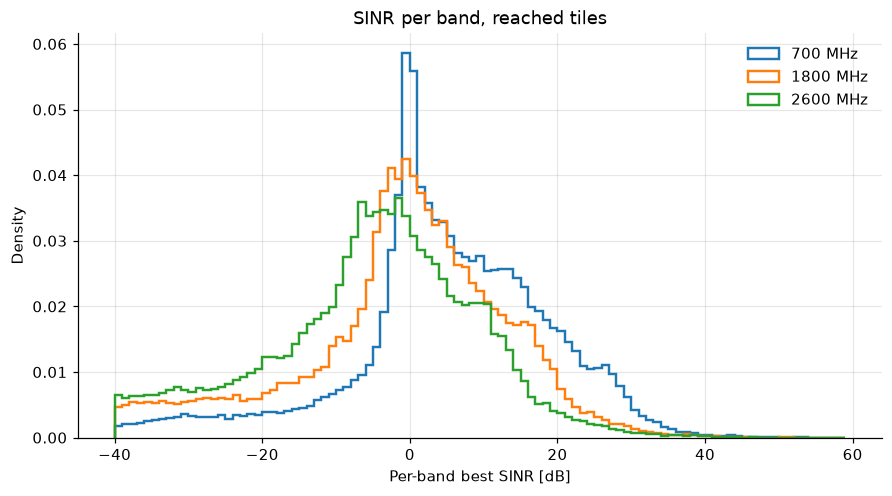

,Value
UE reports,10066.0000
Share not served,0.5882
"Served SINR, 10th percentile [dB]",-1.5759
"Served SINR, median [dB]",3.9879
"PRBs per served UE, median",61.4091


In [31]:
best_sinr_band = {band: capacity.finite(sinr[bands.index(band)]).max(axis=0) for band in by_frequency}
figure, axis = plt.subplots(figsize=(8.0, 4.4), constrained_layout=True)
for band, values in best_sinr_band.items():
    axis.hist(values[np.isfinite(values)], bins=np.arange(-40, 60, 1), histtype="step", lw=1.6, density=True, label=label(band))
axis.set(xlabel="Per-band best SINR [dB]", ylabel="Density", title="SINR per band, reached tiles")
axis.legend()
save_fig(figure, "sinr_distribution")
plt.show()
pd.DataFrame({label(k): v for k, v in service.items() if not k.startswith("share_")}, index=["Value"]).T

### B. Outlier Analysis

In [32]:
outliers = pd.DataFrame(
    [
        {
            "Band": label(band),
            "Values below -156 dBm [%]": 100 * (finite_band[band] < -156).mean(),
            "Tiles above -50 dBm": int((finite_band[band] > -50).sum()),
            "Median distance to nearest node, tiles above -50 dBm [m]": np.median(node_distance[best_per_band[bands.index(band)] > -50]) if (finite_band[band] > -50).any() else np.nan,
            "Minimum [dBm]": finite_band[band].min(),
            "Maximum [dBm]": finite_band[band].max(),
        }
        for band in by_frequency
    ]
)
save_table(outliers, "rsrp_outliers")
outliers

,Band,Values below -156 dBm [%],Tiles above -50 dBm,"Median distance to nearest node, tiles above -50 dBm [m]",Minimum [dBm],Maximum [dBm]
0,700 MHz,0.3534,218,127.8040,-219.2768,-37.6554
1,1800 MHz,1.4947,53,88.8907,-214.9166,-45.7164
2,2600 MHz,3.9627,11,69.9008,-229.9424,-48.9424


The minimum values (below −210 dBm) are deep-shadow paths the ray tracer still found; they are physically
unreportable but classify as holes identically to no-path, so they are retained. The strongest values (up to
−38 dBm) are all within ≈ 130 m of a mast and are genuine near-field coverage. No value exceeds the transmit power.

### C. Data Processing Notes

- **Missing values.** No-path NaN in `rsrp_dbm`/`sinr_db` is kept and read as `-inf` via `src.kpi.capacity.finite`, so
  such tiles count as holes and are never serving candidates. Nothing is imputed.
- **Aggregation.** Per-band best RSRP is the max over cells of one band; best-server RSRP is the max over every
  cell-band (`capacity.max_rsrp`). UE rows are pooled over all 672 intervals unless stated.
- **Coordinates.** Scene metres throughout; rasters are drawn `origin="lower"` on `maps.extent_of`, since row 0 is the lowest y.
- **RSRP thresholding.** `kpi.hole_dbm` and `kpi.weak_dbm` from `configs/kpi.yaml`; no literal thresholds.
- **Serving cell.** Two definitions are shown: the radio argmax (6.2) and the capacity serving rule
  (`capacity.serve_intervals`, with the placeholder settings in `configs/kpi.yaml`).
- **KPIs.** `src.optim.objective.evaluate_kpis`; overlap neighbours from `src.kpi.overlap.overlap_neighbors`.
- **MDT.** `data/interim/mdt.csv` is a subset of the UE rows, matched on every UE column; its `rsrp_dbm` is
  reference only. Section 10.3 compares it with all UE positions.
- **Removal.** None. Outliers and out-of-range values are reported and retained.